In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings
import lightgbm as lgb
import json
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
import warnings


from IPython.display import display, Markdown
from IPython.display import display
from datetime import timedelta
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from datetime import datetime
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Ignore all warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')



# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.5,
})

# Configuration
FORECAST_HORIZONS = [1, 7, 14, 30]
TEST_SIZE_DAYS = 30  # Last 30 days for testing
RANDOM_STATE = 42
LSTM_LOOKBACK = 14
MODEL_DIR = '../models'

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create model directory if it doesn't exist
os.makedirs(MODEL_DIR, exist_ok=True)

print("✓ Imports complete")

✓ Imports complete


<br> <br> <br>

### 1. Creating and Imporing Datasets

In [46]:
# Edges
df_edges_plant = pd.read_csv("../data/SupplyGraph/Edges/Edges (Plant).csv")
df_edges_product_group = pd.read_csv("../data/SupplyGraph/Edges/Edges (Product Group).csv")
df_edges_product_subgroup = pd.read_csv("../data/SupplyGraph/Edges/Edges (Product Sub-Group).csv")
df_edges_storage_location = pd.read_csv("../data/SupplyGraph/Edges/Edges (Storage Location).csv")

# Nodes
df_nodes_productgroup_and_subgroup = pd.read_csv("../data/SupplyGraph/Nodes/Node Types (Product Group and Subgroup).csv")
df_nodes_plant_and_storage = pd.read_csv("../data/SupplyGraph/Nodes/Nodes Type (Plant & Storage).csv")
df_nodes = pd.read_csv("../data/SupplyGraph/Nodes/Nodes.csv")
# df_nodes_index = pd.read_csv("../data/SupplyGraph/Nodes/NodesIndex.csv")

# Temporal
df_temporal_delivery_to_distributor = pd.read_csv("../data/SupplyGraph/Temporal Data/Unit/Delivery To distributor.csv")
df_temporal_factory_issue = pd.read_csv("../data/SupplyGraph/Temporal Data/Unit/Factory Issue.csv")
df_temporal_production = pd.read_csv("../data/SupplyGraph/Temporal Data/Unit/Production.csv")
df_temporal_sales_order = pd.read_csv("../data/SupplyGraph/Temporal Data/Unit/Sales Order.csv")


# Pivot the datasets
df_temporal_sales_order['Date'] = pd.to_datetime(df_temporal_sales_order['Date'])
df_temporal_sales_order_pivot = df_temporal_sales_order.melt(id_vars='Date', var_name='Product', value_name='Sales').dropna()
df_temporal_production['Date'] = pd.to_datetime(df_temporal_production['Date'])
df_temporal_production_pivot = df_temporal_production.melt(id_vars='Date', var_name='Product', value_name='Production Quantity').dropna()
df_temporal_factory_issue['Date'] = pd.to_datetime(df_temporal_factory_issue['Date'])
df_temporal_factory_issue_pivot = df_temporal_factory_issue.melt(id_vars='Date', var_name='Product', value_name='Factory Issue').dropna()
df_temporal_delivery_to_distributor['Date'] = pd.to_datetime(df_temporal_delivery_to_distributor['Date'])
df_temporal_delivery_to_distributor_pivot = df_temporal_delivery_to_distributor.melt(id_vars='Date', var_name='Product', value_name='Distributor').dropna()


# Trading Economics Dataset
df_trading_economics_currency = pd.read_csv("../data/tradingeconomics/Overview/currency.csv", encoding="utf-16")
df_trading_economics_currency["Date"] = pd.to_datetime(df_trading_economics_currency["Date"], dayfirst=True, errors='coerce')

df_trading_economics_stock_market = pd.read_csv("../data/tradingeconomics/Overview/stock_market.csv", encoding="utf-16")
df_trading_economics_stock_market["Date"] = pd.to_datetime(df_trading_economics_stock_market["Date"], dayfirst=True, errors='coerce')

df_trading_economics_interest_rate = pd.read_csv("../data/tradingeconomics/Money/Interest_Rate.csv")
df_trading_economics_interest_rate["DateTime"] = pd.to_datetime(df_trading_economics_interest_rate["DateTime"], errors='coerce')
df_trading_economics_interest_rate["LastUpdate"] = pd.to_datetime(df_trading_economics_interest_rate["LastUpdate"], errors='coerce')

In [47]:
df_trading_economics_currency

,Symbol,Date,Open,High,Low,Close
0,USDBDT:CUR,2026-01-12,122.290,122.485,122.005,122.20
1,USDBDT:CUR,2026-01-09,122.200,122.200,122.200,122.20
2,USDBDT:CUR,2026-01-08,122.295,122.485,122.010,122.20
3,USDBDT:CUR,2026-01-07,122.285,122.475,122.010,122.20
4,USDBDT:CUR,2026-01-06,122.295,122.485,122.010,122.20
...,...,...,...,...,...,...
1330,USDBDT:CUR,2021-01-22,84.290,84.620,84.150,84.15
1331,USDBDT:CUR,2021-01-21,84.800,84.800,84.790,84.79
1332,USDBDT:CUR,2021-01-20,84.790,84.800,84.290,84.29
1333,USDBDT:CUR,2021-01-19,84.800,84.800,84.280,84.28


In [48]:
df_trading_economics_stock_market

,Symbol,Date,Open,High,Low,Close
0,DSEX:IND,2026-01-12,4939.59,4950.07,4918.67,4942.05
1,DSEX:IND,2026-01-11,4998.55,5002.05,4939.59,4939.59
2,DSEX:IND,2026-01-08,4992.70,5011.96,4991.12,4998.55
3,DSEX:IND,2026-01-07,4953.61,5002.81,4953.61,4992.70
4,DSEX:IND,2026-01-06,4954.87,4983.67,4942.22,4953.61
...,...,...,...,...,...,...
1261,DSEX:IND,2021-01-22,5815.55,5815.55,5815.55,5815.55
1262,DSEX:IND,2021-01-21,5836.18,5836.18,5836.18,5836.18
1263,DSEX:IND,2021-01-20,5827.56,5827.56,5827.56,5827.56
1264,DSEX:IND,2021-01-19,5820.80,5820.80,5820.80,5820.80


In [49]:
df_trading_economics_interest_rate

,Country,Category,DateTime,Value,Frequency,HistoricalDataSymbol,LastUpdate
0,Bangladesh,Interest Rate,2008-01-31,8.5,Daily,BangladeshIntRate,2011-06-27 00:00:00
1,Bangladesh,Interest Rate,2008-02-29,8.5,Daily,BangladeshIntRate,2011-06-27 00:00:00
2,Bangladesh,Interest Rate,2008-03-31,8.5,Daily,BangladeshIntRate,2011-06-27 00:00:00
3,Bangladesh,Interest Rate,2008-04-30,8.5,Daily,BangladeshIntRate,2011-06-27 00:00:00
4,Bangladesh,Interest Rate,2008-05-31,8.5,Daily,BangladeshIntRate,2011-06-27 00:00:00
...,...,...,...,...,...,...,...
211,Bangladesh,Interest Rate,2025-08-31,10.0,Daily,BangladeshIntRate,2025-09-02 07:19:00
212,Bangladesh,Interest Rate,2025-09-30,10.0,Daily,BangladeshIntRate,2025-10-02 02:45:00
213,Bangladesh,Interest Rate,2025-10-31,10.0,Daily,BangladeshIntRate,2025-11-04 10:28:00
214,Bangladesh,Interest Rate,2025-11-30,10.0,Daily,BangladeshIntRate,2025-12-04 04:30:00


<br> <br> <br>


#### 1.1 Create a Holiday Dataset

In [50]:
holidays_dict = [
    {
        'Date': '2023-02-21',
        'holiday_type': "National Holiday",
        'holiday_name': "Language Martyrs' Day"
    },
    {
        'Date': "2023-03-8",
        'holiday_type': "National Holiday",
        'holiday_name': "Shab e-barat"
    },   
    {
        'Date': "2023-03-17",
        'holiday_type': "National Holiday",
        'holiday_name': "Sheikh Mujibur Rahman's birthday",
    },
    {
        'Date': "2023-03-26",
        'holiday_type': "National Holiday",
        'holiday_name': "Independence Day",
    },
    {
        'Date': "2023-04-14",
        'holiday_type': "National Holiday",
        'holiday_name': "Bengali New Year" 
    },
    {
        'Date': "2023-04-19",
        'holiday_type': "National Holiday",
        'holiday_name': "Shab-e-Qadr"
    },
    {
        'Date': "2023-04-20",
        'holiday_type': "National Holiday",
        'holiday_name': "Eid al-Fitr"
    },
    {
        'Date': "2023-04-21",
        'holiday_type': "National Holiday",
        'holiday_name': "Jumatul Bidah"
    },
    {
        'Date': "2023-04-22",
        'holiday_type': "National Holiday",
        'holiday_name': "Eid al-Fitr"
    },
    {
        'Date': "2023-04-23",
        'holiday_type': "National Holiday",
        'holiday_name': "Eid al-Fitr"
    },
    {
        'Date': "2023-05-01",
        'holiday_type': "National Holiday",
        'holiday_name': "Labour Day"
    },
    {
        'Date': "2023-05-04",
        'holiday_type': "National Holiday",
        'holiday_name': "Buddha Purnima"
    },
    {
        'Date': "2023-06-27",
        'holiday_type': "National Holiday",
        'holiday_name': "Eid-ul-Azha"
    },
    {
        'Date': "2023-06-28",
        'holiday_type': "National Holiday",
        'holiday_name': "Eid-ul-Azha"
    },
    {
        'Date': "2023-06-29",
        'holiday_type': "National Holiday",
        'holiday_name': "Eid-ul-Azha"
    },
    {
        'Date': "2023-06-30",
        'holiday_type': "National Holiday",
        'holiday_name': "Eid-ul-Azha"
    },
    {
        'Date': "2023-07-01",
        'holiday_type': "Not a National Holiday",
        'holiday_name': "Bank Holiday"
    },
    {
        'Date': "2023-07-29",
        'holiday_type': "National Holiday",
        'holiday_name': "Ashura"
    },
    {
        'Date': "2023-08-15",
        'holiday_type': "National Holiday",
        'holiday_name': "National Mourning Day"
    },       
]


# Create dataframe from holidays_dict
df_holidays = pd.DataFrame(holidays_dict)
df_holidays['Date'] = pd.to_datetime(df_holidays['Date']).dt.normalize()

# Optional: rename for clarity
df_holidays = df_holidays.rename(columns={
    'holiday_name': 'holiday_name',
    'holiday_type': 'holiday_type'
})

# Display the newly created holidays dataframe
display(df_holidays)


,Date,holiday_type,holiday_name
0,2023-02-21,National Holiday,Language Martyrs' Day
1,2023-03-08,National Holiday,Shab e-barat
2,2023-03-17,National Holiday,Sheikh Mujibur Rahman's birthday
3,2023-03-26,National Holiday,Independence Day
4,2023-04-14,National Holiday,Bengali New Year
5,2023-04-19,National Holiday,Shab-e-Qadr
6,2023-04-20,National Holiday,Eid al-Fitr
7,2023-04-21,National Holiday,Jumatul Bidah
8,2023-04-22,National Holiday,Eid al-Fitr
9,2023-04-23,National Holiday,Eid al-Fitr


In [87]:
display(df_holidays["holiday_name"].unique())
display(df_holidays["holiday_type"].unique())

array(["Language Martyrs' Day", 'Shab e-barat',
       "Sheikh Mujibur Rahman's birthday", 'Independence Day',
       'Bengali New Year', 'Shab-e-Qadr', 'Eid al-Fitr', 'Jumatul Bidah',
       'Labour Day', 'Buddha Purnima', 'Eid-ul-Azha', 'Bank Holiday',
       'Ashura', 'National Mourning Day'], dtype=object)

array(['National Holiday', 'Not a National Holiday'], dtype=object)

<br> <br> <br>

#### 1.2 Create a Weather Dataset

In [51]:
def load_weather_data(data_dir='../data/Weather Datasets/Station Wise Data', begin_date='2023-01-01', end_date='2023-08-09'):
    
    import glob
    
    # Convert date strings to datetime
    begin_date = pd.to_datetime(begin_date).normalize()
    end_date = pd.to_datetime(end_date).normalize()
    
    # Get all CSV files in the directory
    csv_files = glob.glob(os.path.join(data_dir, '*.csv'))
    
    if len(csv_files) == 0:
        raise FileNotFoundError(f"No CSV files found in {data_dir}")
    
    print(f"Found {len(csv_files)} CSV files")
    print(f"Date range: {begin_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
    
    all_dfs = []
    
    for file_path in csv_files:
        # Extract city name from filename (remove path and .csv extension)
        city_name = os.path.basename(file_path).replace('.csv', '')
        
        # Read the CSV
        df = pd.read_csv(file_path)
        
        # Add City column
        df['City'] = city_name
        
        # Check if year, month, day columns exist
        year_col = None
        month_col = None
        day_col = None
        
        for col in df.columns:
            col_lower = col.lower()
            if 'year' in col_lower:
                year_col = col
            elif 'month' in col_lower:
                month_col = col
            elif 'day' in col_lower:
                day_col = col
        
        # Create Date column from year, month, day
        if year_col and month_col and day_col:
            df['Date'] = pd.to_datetime(
                df[[year_col, month_col, day_col]].astype(int).rename(
                    columns={year_col: 'year', month_col: 'month', day_col: 'day'}
                )
            ).dt.normalize()
            
            # Drop original year, month, day columns
            df = df.drop(columns=[year_col, month_col, day_col])
            
            # Filter by date range
            df = df[(df['Date'] >= begin_date) & (df['Date'] <= end_date)]
        else:
            # Try to find existing date column
            date_col = None
            for col in df.columns:
                if 'date' in col.lower():
                    date_col = col
                    break
            
            if date_col is not None:
                df['Date'] = pd.to_datetime(df[date_col]).dt.normalize()
                if date_col != 'Date':
                    df = df.drop(columns=[date_col])
                # Filter by date range
                df = df[(df['Date'] >= begin_date) & (df['Date'] <= end_date)]
            else:
                print(f"Warning: No date columns found in {city_name}.csv")
        
        all_dfs.append(df)
        # print(f"  ✓ Loaded {city_name}: {len(df)} rows")
    
    # Concatenate all dataframes
    df_weather = pd.concat(all_dfs, ignore_index=True)
    
    # Reorder columns to put Date and City first
    cols = df_weather.columns.tolist()
    priority_cols = ['Date', 'City']
    other_cols = [c for c in cols if c not in priority_cols]
    df_weather = df_weather[priority_cols + other_cols]
    
    # print(f"\n✓ Combined weather data: {len(df_weather)} total rows")
    # print(f"  Cities: {df_weather['City'].nunique()}")
    # print(f"  Date range in data: {df_weather['Date'].min().strftime('%Y-%m-%d')} to {df_weather['Date'].max().strftime('%Y-%m-%d')}")
    # print(f"  Columns: {list(df_weather.columns)}")
    
    return df_weather


# Load weather data for 2023 with specific date range
df_weather = load_weather_data(
    data_dir='../data/Weather Datasets/Station Wise Data', 
    begin_date='2023-01-01', 
    end_date='2023-08-09'
)

df_weather.drop(columns="Unnamed: 0", inplace=True)

df_weather

Found 35 CSV files
Date range: 2023-01-01 to 2023-08-09


,Date,City,Station,Rainfall,Sunshine,Humidity,Temperature
0,2023-01-01,Ambaganctg,Ambaganctg,0.0,8.3,65.0,20.4
1,2023-01-02,Ambaganctg,Ambaganctg,0.0,8.9,73.0,19.9
2,2023-01-03,Ambaganctg,Ambaganctg,0.0,7.6,80.0,19.9
3,2023-01-04,Ambaganctg,Ambaganctg,0.0,9.4,75.0,20.4
4,2023-01-05,Ambaganctg,Ambaganctg,0.0,8.0,78.0,19.6
...,...,...,...,...,...,...,...
7730,2023-08-05,Teknaf,Teknaf,0.0,10.7,84.0,28.8
7731,2023-08-06,Teknaf,Teknaf,2.0,7.2,80.0,29.0
7732,2023-08-07,Teknaf,Teknaf,0.0,7.7,83.0,28.7
7733,2023-08-08,Teknaf,Teknaf,36.0,0.0,92.0,27.5


In [52]:
# Filter weather data for Ambaganctg (case-insensitive)
city_name = "Dhaka" # 'Ambaganctg', "Dhaka"
df_weather[df_weather['City'].astype(str).str.strip().str.lower() == city_name.lower()]

,Date,City,Station,Rainfall,Sunshine,Humidity,Temperature
1989,2023-01-01,Dhaka,Dhaka,0.0,4.0,81.0,17.9
1990,2023-01-02,Dhaka,Dhaka,0.0,5.5,71.0,19.1
1991,2023-01-03,Dhaka,Dhaka,0.0,0.0,87.0,16.2
1992,2023-01-04,Dhaka,Dhaka,0.0,0.0,91.0,14.8
1993,2023-01-05,Dhaka,Dhaka,0.0,1.3,86.0,15.2
...,...,...,...,...,...,...,...
2205,2023-08-05,Dhaka,Dhaka,55.0,5.7,81.0,29.4
2206,2023-08-06,Dhaka,Dhaka,5.0,5.0,91.0,27.8
2207,2023-08-07,Dhaka,Dhaka,18.0,4.2,95.0,27.4
2208,2023-08-08,Dhaka,Dhaka,54.0,7.1,91.0,27.3


<br> <br> <br>

#### 1.3 Create an Event Dataset

In [53]:
df_events = pd.read_csv("../data/BangladeshEvents/event.csv",  parse_dates=["date"])
df_events

,date,category,name,type,scope_or_location,typical_max_temp_C,typical_min_temp_C,typical_rain_mm,weather_basis,impact_on_supply_chain,notes,source_links
0,2023-01-01,school_university,Start of primary & secondary school academic y...,Academic session start,Nationwide,25.4,12.7,7.7,Dhaka Jan climate normals,"School-related demand (uniforms, books, transp...",Academic year in Bangladesh generally runs Jan...,https://dpe.gov.bd/|https://www.unesco.org/en/...
1,2023-01-13,cultural_event,Bishwa Ijtema 2023 – Phase 1 (13–15 Jan),Mass religious congregation (Tablighi Jamaat),Tongi near Dhaka,25.4,12.7,7.7,Dhaka Jan climate normals,Huge temporary population inflow; heavy pressu...,Event spans 3 days; treat as event window in m...,https://www.thedailystar.net/tags/biswa-ijtema
2,2023-01-20,cultural_event,Bishwa Ijtema 2023 – Phase 2 (20–22 Jan),Mass religious congregation,Tongi near Dhaka,25.4,12.7,7.7,Dhaka Jan climate normals,Similar logistical pattern to Phase 1: congest...,Use as second event window close to Dhaka mark...,https://www.thedailystar.net/tags/biswa-ijtema
3,2023-02-14,cultural_event,Pohela Falgun & Valentine's Day,Cultural festival,Urban centres (esp. Dhaka),28.1,15.5,28.9,Dhaka Feb climate normals,"High footfall in parks, campuses, restaurants;...",Good candidate for positive demand shock in ur...,https://www.thedailystar.net/news/bangladesh/n...
4,2023-02-21,national_holiday,Language Martyrs' Day / International Mother L...,Government/National holiday,Nationwide,28.1,15.5,28.9,Dhaka Feb climate normals,Processions and official ceremonies; governmen...,Can model as national_holiday dummy; demand ef...,https://www.officeholidays.com/countries/bangl...
5,2023-03-08,religious_holiday,Shab-e-Barat,Government holiday,Nationwide,32.5,20.4,65.8,Dhaka Mar climate normals,Night prayers and visits to cemeteries; some b...,Mainly timing effect on working hours and urba...,https://calendarific.com/holiday/bangladesh/sh...
6,2023-03-17,national_holiday,Sheikh Mujibur Rahman's Birthday & National Ch...,Government/National holiday,Nationwide,32.5,20.4,65.8,Dhaka Mar climate normals,Government offices closed; ceremonies and gath...,Include as national_holiday dummy.,https://www.officeholidays.com/countries/bangl...
7,2023-03-23,religious_period,Start of Ramadan 1444 (approx.),Religious fasting month,Nationwide,32.5,20.4,65.8,Dhaka Mar climate normals,"Shift of consumption to evening/night (iftar, ...",Model as month-long behavioural regime change ...,https://www.islamic-relief.org.uk/resources/is...
8,2023-03-26,national_holiday,Independence and National Day,Government/National holiday,Nationwide,32.5,20.4,65.8,Dhaka Mar climate normals,Large rallies and parades; government offices ...,Important national_holiday dummy with possible...,https://www.officeholidays.com/countries/bangl...
9,2023-04-14,cultural_holiday,Bengali New Year (Pohela Boishakh),Government holiday / Cultural new year,Nationwide (strongest in cities),33.7,23.6,156.0,Dhaka Apr climate normals,One of the biggest cultural festivals; very hi...,Strong positive demand shock in retail; possib...,https://www.timeanddate.com/holidays/banglades...


In [54]:
df_events["category"].unique()

array(['school_university', 'cultural_event', 'national_holiday',
       'religious_holiday', 'religious_period', 'cultural_holiday',
       'bank_holiday', 'weather_event', 'infrastructure_event',
       'religious_cultural_holiday', 'political_event'], dtype=object)

<br> <br> <br>

#### 1.4 Create a Currency Exchange Dataset

In [55]:
df_currency_exchange = pd.read_csv("../data/CurrencyExchange/Bangladeshi_Taka_to_USD.csv",  parse_dates=["Date"])
df_currency_exchange

,Date,BDT_USD
0,2023-01-02 23:58:00,104.7776
1,2023-01-03 23:58:00,101.6990
2,2023-01-04 23:58:00,101.9814
3,2023-01-05 23:58:00,102.0143
4,2023-01-06 23:58:00,102.1778
...,...,...
315,2023-12-25 23:58:00,108.3107
316,2023-12-27 23:58:00,108.0956
317,2023-12-28 23:58:00,108.6817
318,2023-12-29 23:58:00,108.1286


<br> <br> <br>

### 2. Calculate the Coefficient of Variation (CV)

In [56]:
def calculate_product_stats(df, group_col='Product', agg_col='Sales'):
    stats = (
        df.groupby(group_col)
          .agg(
              total_units=(agg_col, 'sum'),
              days_with_activity=(agg_col, lambda x: (x > 0).sum()),
              num_days=(agg_col, 'count'),
              avg_daily=(agg_col, 'mean'),
              std_daily=(agg_col, 'std')
          )
    )
    
    stats['activity_frequency'] = stats['days_with_activity'] / stats['num_days']    
    stats['cv'] = stats['std_daily'] / stats['avg_daily']
    # stats['cv'] = stats['cv'].replace([np.inf, -np.inf], np.nan)
    
    # Reset index to make group_col a regular column
    stats = stats.reset_index()
    
    return stats


# Example usage for all temporal dataframes:

# Sales statistics
sales_stats = calculate_product_stats(df_temporal_sales_order_pivot, group_col='Product', agg_col='Sales')
display(Markdown("**Sales Statistics**"))
display(sales_stats)

**Sales Statistics**

,Product,total_units,days_with_activity,num_days,avg_daily,std_daily,activity_frequency,cv
0,AT5X5K,1.782512e+05,174,221,806.566516,938.839092,0.787330,1.163995
1,ATN01K24P,6.393748e+05,179,221,2893.098569,2701.549761,0.809955,0.933791
2,ATN02K12P,1.370076e+05,177,221,619.943831,615.530467,0.800905,0.992881
3,ATPA1K24P,3.100000e+01,1,221,0.140271,2.085286,0.004525,14.866069
4,ATPPCH5X5K,1.000000e+01,1,221,0.045249,0.672673,0.004525,14.866069
5,ATWWP001K24P,9.223728e+03,159,221,41.736327,52.292598,0.719457,1.252928
6,ATWWP002K12P,3.733000e+03,125,221,16.891401,39.055150,0.565611,2.312132
7,EEA200G24P,5.000000e+00,1,221,0.022624,0.336336,0.004525,14.866069
8,EEA500G12P,1.150000e+02,3,221,0.520362,5.250610,0.013575,10.090302
9,MAC1K25P,8.880000e+02,30,221,4.018100,14.922212,0.135747,3.713749


In [57]:
def classify_speed_segment(stats_df, volume_col='total_units', frequency_col='activity_frequency',  q_high=0.8, q_mid=0.5, freq_threshold=0.5):
    
    df = stats_df.copy()
    
    # Calculate quantiles
    q80 = df[volume_col].quantile(q_high) # e.g. 153888.006 = this value changes based on stats_df
    q50 = df[volume_col].quantile(q_mid)  # e.g. 36836.0001 = this value changes based on stats_df
    print(f"q80 = {q80}")
    print(f"q50 = {q50}")
    print(f"Volume Column is: {volume_col}")
    print(f"if ({volume_col} >= {q80}) and ({frequency_col} >= {freq_threshold}) => `Fast`\nelif {volume_col} >= {q50} => `Medium`\nelse => `Slow`")
    print("\n\n")

    # Classification function
    def classify(row):
        if row[volume_col] >= q80 and row[frequency_col] > freq_threshold: # if total_unit > 153888.006 and "activity_frequency (0.7873)" > 0.4 (0.5=default value) 
            return 'Fast'
        elif row[volume_col] >= q50:
            return 'Medium'
        else:
            return 'Slow'
    
    # Apply classification
    df['speed_segment'] = df.apply(classify, axis=1)
    
    return df



# Classify sales statistics
df_stats_classified = classify_speed_segment(
    sales_stats, 
    volume_col='total_units',
    q_high=0.75,  # Top 25% instead of 20%
    q_mid=0.5,
    freq_threshold=0.4  # Lower frequency threshold
)

df_stats_classified

q80 = 153888.006
q50 = 36836.00000000001
Volume Column is: total_units
if (total_units >= 153888.006) and (activity_frequency >= 0.4) => `Fast`
elif total_units >= 36836.00000000001 => `Medium`
else => `Slow`





,Product,total_units,days_with_activity,num_days,avg_daily,std_daily,activity_frequency,cv,speed_segment
0,AT5X5K,1.782512e+05,174,221,806.566516,938.839092,0.787330,1.163995,Fast
1,ATN01K24P,6.393748e+05,179,221,2893.098569,2701.549761,0.809955,0.933791,Fast
2,ATN02K12P,1.370076e+05,177,221,619.943831,615.530467,0.800905,0.992881,Medium
3,ATPA1K24P,3.100000e+01,1,221,0.140271,2.085286,0.004525,14.866069,Slow
4,ATPPCH5X5K,1.000000e+01,1,221,0.045249,0.672673,0.004525,14.866069,Slow
5,ATWWP001K24P,9.223728e+03,159,221,41.736327,52.292598,0.719457,1.252928,Slow
6,ATWWP002K12P,3.733000e+03,125,221,16.891401,39.055150,0.565611,2.312132,Slow
7,EEA200G24P,5.000000e+00,1,221,0.022624,0.336336,0.004525,14.866069,Slow
8,EEA500G12P,1.150000e+02,3,221,0.520362,5.250610,0.013575,10.090302,Slow
9,MAC1K25P,8.880000e+02,30,221,4.018100,14.922212,0.135747,3.713749,Slow



<br> <br> <br>

#### 2.1 – Identify Product

In [58]:
def get_products_by_speed_segment(df_classified, mover='Fast'):
    """
    Get products filtered by speed segment.
    
    Args:
        df_classified: pandas.DataFrame - classified dataframe with 'speed_segment' column
        mover: str or list - speed segment(s) to filter by
               Can be: 'Fast', 'Medium', 'Slow', 'all'
               Or a list: ['Fast', 'Medium'], ['Fast', 'Slow'], etc.
               
    Returns:
        list: List of unique product names matching the specified segment(s)
    """
    valid_segments = ['Fast', 'Medium', 'Slow']
    
    # Handle 'all' case
    if mover == 'all':
        products = df_classified['Product'].dropna().drop_duplicates().tolist()
        print(f"✓ All products: {len(products)} products")
        return products
    
    # Convert single string to list for uniform processing
    if isinstance(mover, str):
        mover = [mover]
    
    # Validate input
    invalid_segments = [m for m in mover if m not in valid_segments]
    if invalid_segments:
        raise ValueError(f"Invalid segment(s): {invalid_segments}. Valid options: {valid_segments}")
    
    # Filter by speed segment(s)
    mask = df_classified['speed_segment'].isin(mover)
    products = df_classified.loc[mask, 'Product'].dropna().drop_duplicates().tolist()
    
    # Print summary
    print(f"\n{'='*70}")
    print(f"PRODUCTS BY SPEED SEGMENT: {mover}")
    print(f"{'='*70}")
    print(f"Total products: {len(products)}")
    
    # Show breakdown by segment
    for segment in mover:
        segment_count = df_classified[df_classified['speed_segment'] == segment]['Product'].nunique()
        print(f"  - {segment}: {segment_count} products")
    
    # Display product details
    for i, product in enumerate(products, 1):
        stats = df_classified[df_classified['Product'] == product].iloc[0]
        print(f"{i:2d}. {product:15s} | Segment: {stats['speed_segment']:6s} | Volume: {stats['total_units']:>10,.0f} | CV: {stats['cv']:.3f} | Activity: {stats['activity_frequency']:.1%}")
    
    return products


# Example usage:

# Get Fast movers only
# FAST_MOVERS = get_products_by_speed_segment(df_stats_classified, mover='Fast')

# Get Medium movers only
# MEDIUM_MOVERS = get_products_by_speed_segment(df_stats_classified, mover='Medium')

# Get Slow movers only
# SLOW_MOVERS = get_products_by_speed_segment(df_stats_classified, mover='Slow')

# Get Fast and Medium movers
# FAST_AND_MEDIUM = get_products_by_speed_segment(df_stats_classified, mover=['Fast', 'Medium'])

# Get all products
ALL_PRODUCTS = get_products_by_speed_segment(df_stats_classified, mover='all')

✓ All products: 41 products


<br> <br> <br>

### 3. Prepare Base Dataset - Merging Dataframes

In [59]:
# Filter for fast movers
MOVERS = ALL_PRODUCTS

# Filter for movers
df_sales_mover = df_temporal_sales_order[['Date'] + MOVERS].copy()
df_production_mover = df_temporal_production[['Date'] + [p for p in MOVERS if p in df_temporal_production.columns]].copy()
df_factory_issue_mover = df_temporal_factory_issue[['Date'] + [p for p in MOVERS if p in df_temporal_factory_issue.columns]].copy()
df_delivery_mover = df_temporal_delivery_to_distributor[['Date'] + [p for p in MOVERS if p in df_temporal_delivery_to_distributor.columns]].copy()


# Pivot to long format
df_sales_long = df_sales_mover.melt(id_vars='Date', var_name='Product', value_name='Sales')
df_production_long = df_production_mover.melt(id_vars='Date', var_name='Product', value_name='Production')
df_factory_issue_long = df_factory_issue_mover.melt(id_vars='Date', var_name='Product', value_name='Factory_Issue')
df_delivery_long = df_delivery_mover.melt(id_vars='Date', var_name='Product', value_name='Delivery')

# Merge all temporal data
df_base = df_sales_long.merge(df_production_long, on=['Date', 'Product'], how='left')
df_base = df_base.merge(df_factory_issue_long, on=['Date', 'Product'], how='left')
df_base = df_base.merge(df_delivery_long, on=['Date', 'Product'], how='left')

# Fill NaN with 0 (no activity)
df_base = df_base.fillna(0)

# Sort by Product and Date
df_base = df_base.sort_values(['Product', 'Date']).reset_index(drop=True)

# Add Product, Group and Sub-Group
df_meta_filtered = df_nodes_productgroup_and_subgroup.rename(columns={'Node': 'Product'})
df_base = df_base.merge(df_meta_filtered[['Product', 'Group', 'Sub-Group']], on='Product', how='left')

print(f"Base dataset shape: {df_base.shape}")
print(f"\nColumns: {list(df_base.columns)}")
print(f"\nDate range: {df_base['Date'].min()} to {df_base['Date'].max()}")
print(f"Number of products: {df_base['Product'].nunique()}")
print(f"Total records: {len(df_base):,}")

df_base = df_base.drop_duplicates().reset_index(drop=True)
df_base

Base dataset shape: (9282, 8)

Columns: ['Date', 'Product', 'Sales', 'Production', 'Factory_Issue', 'Delivery', 'Group', 'Sub-Group']

Date range: 2023-01-01 00:00:00 to 2023-08-09 00:00:00
Number of products: 41
Total records: 9,282


,Date,Product,Sales,Production,Factory_Issue,Delivery,Group,Sub-Group
0,2023-01-01,AT5X5K,2642.0,1500,970.0,707.0,A,AT
1,2023-01-02,AT5X5K,1070.0,1500,1720.0,2317.0,A,AT
2,2023-01-03,AT5X5K,2355.0,2000,2964.0,2215.6,A,AT
3,2023-01-04,AT5X5K,909.8,2000,2265.0,2439.0,A,AT
4,2023-01-05,AT5X5K,3504.0,2000,1100.0,735.8,A,AT
...,...,...,...,...,...,...,...,...
9056,2023-08-05,SOS500M24P,109.0,1203,1709.0,1477.0,S,SOS
9057,2023-08-06,SOS500M24P,2897.0,1000,1735.0,1179.0,S,SOS
9058,2023-08-07,SOS500M24P,2385.0,2000,1675.0,2506.0,S,SOS
9059,2023-08-08,SOS500M24P,0.0,1024,445.0,500.0,S,SOS


In [60]:
# Prepare dataframes for merging

# 1. Filter weather data for Dhaka only
df_weather_dhaka = df_weather[df_weather['City'].str.lower() == 'dhaka'].copy()
df_weather_dhaka = df_weather_dhaka.drop(columns=['City'])  # Remove City column since it's always Dhaka

# 2. Prepare events dataframe (rename 'date' to 'Date' for consistency)
df_events_clean = df_events.copy()
df_events_clean = df_events_clean.rename(columns={'date': 'Date'})
df_events_clean['Date'] = pd.to_datetime(df_events_clean['Date']).dt.normalize()

# 3. Prepare currency exchange dataframe
df_currency_clean = df_currency_exchange.copy()
df_currency_clean['Date'] = pd.to_datetime(df_currency_clean['Date']).dt.normalize()

# 4. Prepare holidays dataframe
df_holidays_clean = df_holidays.copy()
df_holidays_clean['Date'] = pd.to_datetime(df_holidays_clean['Date']).dt.normalize()

# 5. Ensure df_base Date is normalized
df_base['Date'] = pd.to_datetime(df_base['Date']).dt.normalize()

# Merge all dataframes
print("Merging dataframes...")

# Merge with holidays
df_merged = df_base.merge(df_holidays_clean, on='Date', how='left')
print(f"  ✓ Merged with holidays: {df_merged.shape}")

# Merge with weather (Dhaka only)
df_merged = df_merged.merge(df_weather_dhaka, on='Date', how='left')
print(f"  ✓ Merged with weather (Dhaka): {df_merged.shape}")

# Merge with events
df_merged = df_merged.merge(df_events_clean, on='Date', how='left')
print(f"  ✓ Merged with events: {df_merged.shape}")

# Merge with currency exchange
df_merged = df_merged.merge(df_currency_clean, on='Date', how='left')
print(f"  ✓ Merged with currency exchange: {df_merged.shape}")

# Fill NaN for categorical columns
if 'Holiday' in df_merged.columns:
    df_merged['Holiday'] = df_merged['Holiday'].fillna('no_holiday')
if 'category' in df_merged.columns:
    df_merged['category'] = df_merged['category'].fillna('no_event')

df_merged

df_merged.drop(columns=["name", "type", "typical_max_temp_C", "typical_min_temp_C", "weather_basis", "impact_on_supply_chain", "notes", "source_links"], inplace=True)

Merging dataframes...
  ✓ Merged with holidays: (9061, 10)
  ✓ Merged with weather (Dhaka): (9061, 15)
  ✓ Merged with events: (9061, 26)
  ✓ Merged with currency exchange: (9061, 27)


In [61]:
df_merged

,Date,Product,Sales,Production,Factory_Issue,Delivery,Group,Sub-Group,holiday_type,holiday_name,Station,Rainfall,Sunshine,Humidity,Temperature,category,scope_or_location,typical_rain_mm,BDT_USD
0,2023-01-01,AT5X5K,2642.0,1500,970.0,707.0,A,AT,NaN,NaN,Dhaka,0.0,4.0,81.0,17.9,school_university,Nationwide,7.7,NaN
1,2023-01-02,AT5X5K,1070.0,1500,1720.0,2317.0,A,AT,NaN,NaN,Dhaka,0.0,5.5,71.0,19.1,no_event,NaN,NaN,104.7776
2,2023-01-03,AT5X5K,2355.0,2000,2964.0,2215.6,A,AT,NaN,NaN,Dhaka,0.0,0.0,87.0,16.2,no_event,NaN,NaN,101.6990
3,2023-01-04,AT5X5K,909.8,2000,2265.0,2439.0,A,AT,NaN,NaN,Dhaka,0.0,0.0,91.0,14.8,no_event,NaN,NaN,101.9814
4,2023-01-05,AT5X5K,3504.0,2000,1100.0,735.8,A,AT,NaN,NaN,Dhaka,0.0,1.3,86.0,15.2,no_event,NaN,NaN,102.0143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9056,2023-08-05,SOS500M24P,109.0,1203,1709.0,1477.0,S,SOS,NaN,NaN,Dhaka,55.0,5.7,81.0,29.4,weather_event,Chattogram division & south-east,316.5,106.5524
9057,2023-08-06,SOS500M24P,2897.0,1000,1735.0,1179.0,S,SOS,NaN,NaN,Dhaka,5.0,5.0,91.0,27.8,no_event,NaN,NaN,106.6636
9058,2023-08-07,SOS500M24P,2385.0,2000,1675.0,2506.0,S,SOS,NaN,NaN,Dhaka,18.0,4.2,95.0,27.4,no_event,NaN,NaN,107.6734
9059,2023-08-08,SOS500M24P,0.0,1024,445.0,500.0,S,SOS,NaN,NaN,Dhaka,54.0,7.1,91.0,27.3,no_event,NaN,NaN,107.7798


## 4. Feature Engineering Pipeline

### 4.1 Temporal Features (Lags and Rolling Windows)

In [62]:
def create_lag_features(df, target_col='Sales', lags=[1, 2, 3, 7, 14, 21, 28]):
    """
    Create lag features for each product
    """
    df_feat = df.copy()
    
    for lag in lags:
        df_feat[f'{target_col}_lag_{lag}'] = df_feat.groupby('Product')[target_col].shift(lag)
    
    return df_feat

def create_rolling_features(df, target_col='Sales', windows=[7, 14, 30]):
    """
    Create rolling window statistics
    """
    df_feat = df.copy()
    
    for window in windows:
        # Rolling mean
        df_feat[f'{target_col}_rolling_mean_{window}'] = (
            df_feat.groupby('Product')[target_col]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )
        
        # Rolling std
        df_feat[f'{target_col}_rolling_std_{window}'] = (
            df_feat.groupby('Product')[target_col]
            .transform(lambda x: x.rolling(window=window, min_periods=1).std())
        )
        
        # Rolling min/max
        df_feat[f'{target_col}_rolling_min_{window}'] = (
            df_feat.groupby('Product')[target_col]
            .transform(lambda x: x.rolling(window=window, min_periods=1).min())
        )
        
        df_feat[f'{target_col}_rolling_max_{window}'] = (
            df_feat.groupby('Product')[target_col]
            .transform(lambda x: x.rolling(window=window, min_periods=1).max())
        )
    
    return df_feat

# Apply lag features and rolling features for Sales
# print("Creating lag and rolling window features for Sales...")
df_features = create_lag_features(df_merged, target_col='Sales', lags=[1, 2, 3, 7, 14, 21, 28])
# df_features = create_rolling_features(df_features, target_col='Sales', windows=[7, 14, 30])

# Also create features for Production, Factory_Issue, Delivery
# print("Creating lag and rolling window features for Production...")
# df_features = create_lag_features(df_features, target_col='Production', lags=[1, 7, 14])
# df_features = create_rolling_features(df_features, target_col='Production', windows=[1, 7, 14])

# print("Creating lag and rolling window features for Sales...")
# df_features = create_lag_features(df_features, target_col='Factory_Issue', lags=[1, 7, 14])
# df_features = create_rolling_features(df_features, target_col='Factory_Issue', windows=[1, 7, 14])

# print("Creating features for Delivery...")
# df_features = create_lag_features(df_features, target_col='Delivery', lags=[1, 7, 14])
# df_features = create_rolling_features(df_features, target_col='Delivery', windows=[1, 7, 14])

print(f"\n✓ Temporal features created")
print(f"Total features: {df_features.shape[1]}")


✓ Temporal features created
Total features: 26


In [63]:
df_features.head()

,Date,Product,Sales,Production,Factory_Issue,Delivery,Group,Sub-Group,holiday_type,holiday_name,Station,Rainfall,Sunshine,Humidity,Temperature,category,scope_or_location,typical_rain_mm,BDT_USD,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28
0,2023-01-01,AT5X5K,2642.0,1500,970.0,707.0,A,AT,NaN,NaN,Dhaka,0.0,4.0,81.0,17.9,school_university,Nationwide,7.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-02,AT5X5K,1070.0,1500,1720.0,2317.0,A,AT,NaN,NaN,Dhaka,0.0,5.5,71.0,19.1,no_event,NaN,NaN,104.7776,2642.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-01-03,AT5X5K,2355.0,2000,2964.0,2215.6,A,AT,NaN,NaN,Dhaka,0.0,0.0,87.0,16.2,no_event,NaN,NaN,101.6990,1070.0,2642.0,NaN,NaN,NaN,NaN,NaN
3,2023-01-04,AT5X5K,909.8,2000,2265.0,2439.0,A,AT,NaN,NaN,Dhaka,0.0,0.0,91.0,14.8,no_event,NaN,NaN,101.9814,2355.0,1070.0,2642.0,NaN,NaN,NaN,NaN
4,2023-01-05,AT5X5K,3504.0,2000,1100.0,735.8,A,AT,NaN,NaN,Dhaka,0.0,1.3,86.0,15.2,no_event,NaN,NaN,102.0143,909.8,2355.0,1070.0,NaN,NaN,NaN,NaN


In [64]:
def create_supply_chain_features(df):
    """
    Create features capturing supply chain dynamics
    """
    df_feat = df.copy()
    
    # Production-to-sales ratio
    df_feat['production_sales_ratio'] = (df_feat['Production'] / (df_feat['Sales'] + 1e-6))
    
    # Delivery-to-sales ratio
    df_feat['delivery_sales_ratio'] = (df_feat['Delivery'] / (df_feat['Sales'] + 1e-6))
    
    # Factory issue rate (relative to production)
    df_feat['factory_issue_rate'] = (df_feat['Factory_Issue'] / (df_feat['Production'] + 1e-6))
    
    # Cumulative inventory proxy (cumsum of production - sales)
    df_feat['inventory_proxy'] = (
        df_feat.groupby('Product').apply(
            lambda x: (x['Production'] - x['Sales']).cumsum()
        ).reset_index(level=0, drop=True)
    )
    
    # Replace inf with NaN
    df_feat = df_feat.replace([np.inf, -np.inf], np.nan)
    
    return df_feat

print("Creating supply chain interaction features...")
df_features = create_supply_chain_features(df_features)

print(f"✓ Supply chain features created")
print(f"Total features: {df_features.shape[1]}")

Creating supply chain interaction features...
✓ Supply chain features created
Total features: 30


In [65]:
df_features

,Date,Product,Sales,Production,Factory_Issue,Delivery,Group,Sub-Group,holiday_type,holiday_name,Station,Rainfall,Sunshine,Humidity,Temperature,category,scope_or_location,typical_rain_mm,BDT_USD,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,production_sales_ratio,delivery_sales_ratio,factory_issue_rate,inventory_proxy
0,2023-01-01,AT5X5K,2642.0,1500,970.0,707.0,A,AT,NaN,NaN,Dhaka,0.0,4.0,81.0,17.9,school_university,Nationwide,7.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.677517e-01,2.676003e-01,0.646667,-1142.000000
1,2023-01-02,AT5X5K,1070.0,1500,1720.0,2317.0,A,AT,NaN,NaN,Dhaka,0.0,5.5,71.0,19.1,no_event,NaN,NaN,104.7776,2642.0,NaN,NaN,NaN,NaN,NaN,NaN,1.401869e+00,2.165421e+00,1.146667,-712.000000
2,2023-01-03,AT5X5K,2355.0,2000,2964.0,2215.6,A,AT,NaN,NaN,Dhaka,0.0,0.0,87.0,16.2,no_event,NaN,NaN,101.6990,1070.0,2642.0,NaN,NaN,NaN,NaN,NaN,8.492569e-01,9.408068e-01,1.482000,-1067.000000
3,2023-01-04,AT5X5K,909.8,2000,2265.0,2439.0,A,AT,NaN,NaN,Dhaka,0.0,0.0,91.0,14.8,no_event,NaN,NaN,101.9814,2355.0,1070.0,2642.0,NaN,NaN,NaN,NaN,2.198285e+00,2.680809e+00,1.132500,23.200000
4,2023-01-05,AT5X5K,3504.0,2000,1100.0,735.8,A,AT,NaN,NaN,Dhaka,0.0,1.3,86.0,15.2,no_event,NaN,NaN,102.0143,909.8,2355.0,1070.0,NaN,NaN,NaN,NaN,5.707763e-01,2.099886e-01,0.550000,-1480.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9056,2023-08-05,SOS500M24P,109.0,1203,1709.0,1477.0,S,SOS,NaN,NaN,Dhaka,55.0,5.7,81.0,29.4,weather_event,Chattogram division & south-east,316.5,106.5524,0.0,3669.0,2335.0,0.0,184.0,236.0,513.0,1.103670e+01,1.355046e+01,1.420615,-3956.025996
9057,2023-08-06,SOS500M24P,2897.0,1000,1735.0,1179.0,S,SOS,NaN,NaN,Dhaka,5.0,5.0,91.0,27.8,no_event,NaN,NaN,106.6636,109.0,0.0,3669.0,3810.0,4241.0,4169.0,4971.0,3.451847e-01,4.069727e-01,1.735000,-5853.025996
9058,2023-08-07,SOS500M24P,2385.0,2000,1675.0,2506.0,S,SOS,NaN,NaN,Dhaka,18.0,4.2,95.0,27.4,no_event,NaN,NaN,107.6734,2897.0,109.0,0.0,2454.0,2326.0,2214.0,3291.0,8.385744e-01,1.050734e+00,0.837500,-6238.025996
9059,2023-08-08,SOS500M24P,0.0,1024,445.0,500.0,S,SOS,NaN,NaN,Dhaka,54.0,7.1,91.0,27.3,no_event,NaN,NaN,107.7798,2385.0,2897.0,109.0,2528.0,1390.0,1804.0,2124.0,1.024000e+09,5.000000e+08,0.434570,-5214.025996


### Scaling and Encoding the data

In [66]:

def scale_and_encode_features(df, features_for_scaling=None, excluded_features=None, no_need_for_scaling_features=None, categorical_features=None, encoding_method='onehot', auto_scale_remaining=True):
    
    from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
    
    # Initialize lists if None
    if excluded_features is None:
        excluded_features = []
    if no_need_for_scaling_features is None:
        no_need_for_scaling_features = []
    if categorical_features is None:
        categorical_features = []
    
    # Auto-determine features_for_scaling if not provided and auto_scale_remaining is True
    if features_for_scaling is None and auto_scale_remaining:
        all_features = set(df.columns)
        excluded_set = set(excluded_features + no_need_for_scaling_features + categorical_features)
        features_for_scaling = list(all_features - excluded_set)
        print(f"✓ Auto-selected {len(features_for_scaling)} features for scaling: {features_for_scaling[:5]}..." if len(features_for_scaling) > 5 else f"✓ Auto-selected {len(features_for_scaling)} features for scaling: {features_for_scaling}")
    elif features_for_scaling is None:
        features_for_scaling = []
    
    # Create a copy of the dataframe
    df_processed = df.copy()
    
    # Initialize scaler and encoder info
    scaler = MinMaxScaler()
    encoders = {}
    encoded_feature_names = []
    
    # 1. Scale numerical features
    valid_scaling_features = [f for f in features_for_scaling if f in df.columns]
    if len(valid_scaling_features) > 0:
        df_processed[valid_scaling_features] = scaler.fit_transform(df[valid_scaling_features])
        print(f"✓ Scaled {len(valid_scaling_features)} features using MinMaxScaler")
    
    # 2. Encode categorical features
    valid_categorical_features = [f for f in categorical_features if f in df.columns]
    
    if len(valid_categorical_features) > 0:
        if encoding_method == 'onehot':
            # OneHot Encoding
            encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
            encoded_data = encoder.fit_transform(df[valid_categorical_features])
            
            # Get feature names
            encoded_feature_names = encoder.get_feature_names_out(valid_categorical_features)
            
            # Create dataframe with encoded features
            encoded_df = pd.DataFrame(encoded_data, columns=encoded_feature_names, index=df.index)
            
            # Drop original categorical columns and add encoded ones
            df_processed = df_processed.drop(columns=valid_categorical_features)
            df_processed = pd.concat([df_processed, encoded_df], axis=1)
            
            encoders['onehot'] = encoder
            print(f"✓ OneHot encoded {len(valid_categorical_features)} categorical features into {len(encoded_feature_names)} columns")
            
        elif encoding_method == 'label':
            # Label Encoding (each feature separately)
            for feature in valid_categorical_features:
                encoder = LabelEncoder()
                df_processed[feature] = encoder.fit_transform(df[feature].astype(str))
                encoders[f'label_{feature}'] = encoder
            
            print(f"✓ Label encoded {len(valid_categorical_features)} categorical features")
            
        elif encoding_method == 'ordinal':
            # Ordinal Encoding
            encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            df_processed[valid_categorical_features] = encoder.fit_transform(df[valid_categorical_features].astype(str))
            encoders['ordinal'] = encoder
            print(f"✓ Ordinal encoded {len(valid_categorical_features)} categorical features")
    
    # Create metadata dictionary
    processing_info = {
        'scaler': scaler,
        'encoders': encoders,
        'scaled_features': valid_scaling_features,
        'categorical_features': valid_categorical_features,
        'encoded_feature_names': list(encoded_feature_names),
        'excluded_features': excluded_features,
        'no_scaling_features': no_need_for_scaling_features,
        'encoding_method': encoding_method,
        'auto_scaled': auto_scale_remaining and features_for_scaling is None
    }
    
    print(f"\nFinal shape: {df_processed.shape}")
    
    return df_processed, processing_info



In [67]:
# cols = ["day_of_week", "day_of_month", "week_of_year", "month", "quarter","is_weekend", "day_of_year"] # dropped because I have all of these values with cos and sin.
# df_features_removed = df_features.drop(columns=cols)
# df_features_removed

In [68]:
df_features

,Date,Product,Sales,Production,Factory_Issue,Delivery,Group,Sub-Group,holiday_type,holiday_name,Station,Rainfall,Sunshine,Humidity,Temperature,category,scope_or_location,typical_rain_mm,BDT_USD,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,production_sales_ratio,delivery_sales_ratio,factory_issue_rate,inventory_proxy
0,2023-01-01,AT5X5K,2642.0,1500,970.0,707.0,A,AT,NaN,NaN,Dhaka,0.0,4.0,81.0,17.9,school_university,Nationwide,7.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.677517e-01,2.676003e-01,0.646667,-1142.000000
1,2023-01-02,AT5X5K,1070.0,1500,1720.0,2317.0,A,AT,NaN,NaN,Dhaka,0.0,5.5,71.0,19.1,no_event,NaN,NaN,104.7776,2642.0,NaN,NaN,NaN,NaN,NaN,NaN,1.401869e+00,2.165421e+00,1.146667,-712.000000
2,2023-01-03,AT5X5K,2355.0,2000,2964.0,2215.6,A,AT,NaN,NaN,Dhaka,0.0,0.0,87.0,16.2,no_event,NaN,NaN,101.6990,1070.0,2642.0,NaN,NaN,NaN,NaN,NaN,8.492569e-01,9.408068e-01,1.482000,-1067.000000
3,2023-01-04,AT5X5K,909.8,2000,2265.0,2439.0,A,AT,NaN,NaN,Dhaka,0.0,0.0,91.0,14.8,no_event,NaN,NaN,101.9814,2355.0,1070.0,2642.0,NaN,NaN,NaN,NaN,2.198285e+00,2.680809e+00,1.132500,23.200000
4,2023-01-05,AT5X5K,3504.0,2000,1100.0,735.8,A,AT,NaN,NaN,Dhaka,0.0,1.3,86.0,15.2,no_event,NaN,NaN,102.0143,909.8,2355.0,1070.0,NaN,NaN,NaN,NaN,5.707763e-01,2.099886e-01,0.550000,-1480.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9056,2023-08-05,SOS500M24P,109.0,1203,1709.0,1477.0,S,SOS,NaN,NaN,Dhaka,55.0,5.7,81.0,29.4,weather_event,Chattogram division & south-east,316.5,106.5524,0.0,3669.0,2335.0,0.0,184.0,236.0,513.0,1.103670e+01,1.355046e+01,1.420615,-3956.025996
9057,2023-08-06,SOS500M24P,2897.0,1000,1735.0,1179.0,S,SOS,NaN,NaN,Dhaka,5.0,5.0,91.0,27.8,no_event,NaN,NaN,106.6636,109.0,0.0,3669.0,3810.0,4241.0,4169.0,4971.0,3.451847e-01,4.069727e-01,1.735000,-5853.025996
9058,2023-08-07,SOS500M24P,2385.0,2000,1675.0,2506.0,S,SOS,NaN,NaN,Dhaka,18.0,4.2,95.0,27.4,no_event,NaN,NaN,107.6734,2897.0,109.0,0.0,2454.0,2326.0,2214.0,3291.0,8.385744e-01,1.050734e+00,0.837500,-6238.025996
9059,2023-08-08,SOS500M24P,0.0,1024,445.0,500.0,S,SOS,NaN,NaN,Dhaka,54.0,7.1,91.0,27.3,no_event,NaN,NaN,107.7798,2385.0,2897.0,109.0,2528.0,1390.0,1804.0,2124.0,1.024000e+09,5.000000e+08,0.434570,-5214.025996


In [69]:
def merge_trading_economics_data(df_features, merging_trading_economics_status=False):
    """
    Merge trading economics data with df_features based on Date column.
    
    Parameters:
    -----------
    df_features : pd.DataFrame
        Base dataframe with a 'Date' column
    merging_trading_economics_status : bool
        If True, merges trading economics dataframes with df_features
        
    Returns:
    --------
    pd.DataFrame
        Merged dataframe with trading economics data if merging_trading_economics_status is True,
        otherwise returns df_features unchanged
    """
    if not merging_trading_economics_status:
        print("Trading economics merging is disabled. Returning original df_features.")
        return df_features.copy()
    
    print("Merging trading economics data...")
    df_merged = df_features.copy()
    
    # Ensure Date column is datetime and normalized
    df_merged['Date'] = pd.to_datetime(df_merged['Date']).dt.normalize()
    
    # 1. Merge with currency data (Open, High, Low, Close)
    df_currency_subset = df_trading_economics_currency[['Date', 'Open', 'High', 'Low', 'Close']].copy()
    df_currency_subset['Date'] = pd.to_datetime(df_currency_subset['Date']).dt.normalize()
    df_currency_subset = df_currency_subset.rename(columns={
        'Open': 'currency_open',
        'High': 'currency_high',
        'Low': 'currency_low',
        'Close': 'currency_close'
    })
    df_merged = df_merged.merge(df_currency_subset, on='Date', how='left')
    print(f"  ✓ Merged with currency data: {df_merged.shape}")
    
    # 2. Merge with interest rate data (Value)
    df_interest_subset = df_trading_economics_interest_rate[['DateTime', 'Value']].copy()
    df_interest_subset['DateTime'] = pd.to_datetime(df_interest_subset['DateTime']).dt.normalize()
    df_interest_subset = df_interest_subset.rename(columns={
        'DateTime': 'Date',
        'Value': 'interest_rate_value'
    })
    df_merged = df_merged.merge(df_interest_subset, on='Date', how='left')
    print(f"  ✓ Merged with interest rate data: {df_merged.shape}")
    
    # 3. Merge with stock market data (Open, High, Low, Close)
    df_stock_subset = df_trading_economics_stock_market[['Date', 'Open', 'High', 'Low', 'Close']].copy()
    df_stock_subset['Date'] = pd.to_datetime(df_stock_subset['Date']).dt.normalize()
    df_stock_subset = df_stock_subset.rename(columns={
        'Open': 'stock_market_open',
        'High': 'stock_market_high',
        'Low': 'stock_market_low',
        'Close': 'stock_market_close'
    })
    df_merged = df_merged.merge(df_stock_subset, on='Date', how='left')
    print(f"  ✓ Merged with stock market data: {df_merged.shape}")
    
    print(f"\n✓ Trading economics data merged successfully!")
    print(f"  Added columns: {[col for col in df_merged.columns if col not in df_features.columns]}")
    
    return df_merged


# Example usage:
df_features.drop(columns=["BDT_USD"], inplace=True)
df_features = merge_trading_economics_data(df_features, merging_trading_economics_status=True)

Merging trading economics data...
  ✓ Merged with currency data: (9061, 33)
  ✓ Merged with interest rate data: (9061, 34)
  ✓ Merged with stock market data: (9061, 38)

✓ Trading economics data merged successfully!
  Added columns: ['currency_open', 'currency_high', 'currency_low', 'currency_close', 'interest_rate_value', 'stock_market_open', 'stock_market_high', 'stock_market_low', 'stock_market_close']


In [70]:
df_features

,Date,Product,Sales,Production,Factory_Issue,Delivery,Group,Sub-Group,holiday_type,holiday_name,Station,Rainfall,Sunshine,Humidity,Temperature,category,scope_or_location,typical_rain_mm,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,production_sales_ratio,delivery_sales_ratio,factory_issue_rate,inventory_proxy,currency_open,currency_high,currency_low,currency_close,interest_rate_value,stock_market_open,stock_market_high,stock_market_low,stock_market_close
0,2023-01-01,AT5X5K,2642.0,1500,970.0,707.0,A,AT,NaN,NaN,Dhaka,0.0,4.0,81.0,17.9,school_university,Nationwide,7.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.677517e-01,2.676003e-01,0.646667,-1142.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-02,AT5X5K,1070.0,1500,1720.0,2317.0,A,AT,NaN,NaN,Dhaka,0.0,5.5,71.0,19.1,no_event,NaN,NaN,2642.0,NaN,NaN,NaN,NaN,NaN,NaN,1.401869e+00,2.165421e+00,1.146667,-712.000000,103.25,105.95,102.84,105.95,NaN,6177.88,6177.88,6177.88,6177.88
2,2023-01-03,AT5X5K,2355.0,2000,2964.0,2215.6,A,AT,NaN,NaN,Dhaka,0.0,0.0,87.0,16.2,no_event,NaN,NaN,1070.0,2642.0,NaN,NaN,NaN,NaN,NaN,8.492569e-01,9.408068e-01,1.482000,-1067.000000,106.00,106.00,103.26,103.35,NaN,6185.06,6185.06,6185.06,6185.06
3,2023-01-04,AT5X5K,909.8,2000,2265.0,2439.0,A,AT,NaN,NaN,Dhaka,0.0,0.0,91.0,14.8,no_event,NaN,NaN,2355.0,1070.0,2642.0,NaN,NaN,NaN,NaN,2.198285e+00,2.680809e+00,1.132500,23.200000,106.00,106.00,103.28,103.30,NaN,6202.63,6202.63,6202.63,6202.63
4,2023-01-05,AT5X5K,3504.0,2000,1100.0,735.8,A,AT,NaN,NaN,Dhaka,0.0,1.3,86.0,15.2,no_event,NaN,NaN,909.8,2355.0,1070.0,NaN,NaN,NaN,NaN,5.707763e-01,2.099886e-01,0.550000,-1480.800000,106.00,106.00,103.50,103.50,NaN,6193.96,6193.96,6193.96,6193.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9056,2023-08-05,SOS500M24P,109.0,1203,1709.0,1477.0,S,SOS,NaN,NaN,Dhaka,55.0,5.7,81.0,29.4,weather_event,Chattogram division & south-east,316.5,0.0,3669.0,2335.0,0.0,184.0,236.0,513.0,1.103670e+01,1.355046e+01,1.420615,-3956.025996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9057,2023-08-06,SOS500M24P,2897.0,1000,1735.0,1179.0,S,SOS,NaN,NaN,Dhaka,5.0,5.0,91.0,27.8,no_event,NaN,NaN,109.0,0.0,3669.0,3810.0,4241.0,4169.0,4971.0,3.451847e-01,4.069727e-01,1.735000,-5853.025996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9058,2023-08-07,SOS500M24P,2385.0,2000,1675.0,2506.0,S,SOS,NaN,NaN,Dhaka,18.0,4.2,95.0,27.4,no_event,NaN,NaN,2897.0,109.0,0.0,2454.0,2326.0,2214.0,3291.0,8.385744e-01,1.050734e+00,0.837500,-6238.025996,109.40,109.40,109.33,109.33,NaN,6299.66,6299.66,6299.66,6299.66
9059,2023-08-08,SOS500M24P,0.0,1024,445.0,500.0,S,SOS,NaN,NaN,Dhaka,54.0,7.1,91.0,27.3,no_event,NaN,NaN,2385.0,2897.0,109.0,2528.0,1390.0,1804.0,2124.0,1.024000e+09,5.000000e+08,0.434570,-5214.025996,109.40,109.40,109.00,109.40,NaN,6315.57,6315.57,6315.57,6315.57


In [71]:
df_features.columns

Index(['Date', 'Product', 'Sales', 'Production', 'Factory_Issue', 'Delivery',
       'Group', 'Sub-Group', 'holiday_type', 'holiday_name', 'Station',
       'Rainfall', 'Sunshine', 'Humidity', 'Temperature', 'category',
       'scope_or_location', 'typical_rain_mm', 'Sales_lag_1', 'Sales_lag_2',
       'Sales_lag_3', 'Sales_lag_7', 'Sales_lag_14', 'Sales_lag_21',
       'Sales_lag_28', 'production_sales_ratio', 'delivery_sales_ratio',
       'factory_issue_rate', 'inventory_proxy', 'currency_open',
       'currency_high', 'currency_low', 'currency_close',
       'interest_rate_value', 'stock_market_open', 'stock_market_high',
       'stock_market_low', 'stock_market_close'],
      dtype='object')

| Feature Name | Source DataFrame | Dataset Name |
|---|---|---|
| `Date` | `df_base` / `df_temporal_sales_order` | SupplyGraph — `Temporal Data/Unit/Sales Order.csv` |
| `Product` | `df_base` / `df_temporal_sales_order` | SupplyGraph — `Temporal Data/Unit/Sales Order.csv` |
| `Sales` | `df_sales_long` ← `df_temporal_sales_order` | SupplyGraph — `Temporal Data/Unit/Sales Order.csv` |
| `Production` | `df_production_long` ← `df_temporal_production` | SupplyGraph — `Temporal Data/Unit/Production.csv` |
| `Factory_Issue` | `df_factory_issue_long` ← `df_temporal_factory_issue` | SupplyGraph — `Temporal Data/Unit/Factory Issue.csv` |
| `Delivery` | `df_delivery_long` ← `df_temporal_delivery_to_distributor` | SupplyGraph — `Temporal Data/Unit/Delivery To distributor.csv` |
| `Group` | `df_meta_filtered` ← `df_nodes_productgroup_and_subgroup` | SupplyGraph — `Nodes/Node Types (Product Group and Subgroup).csv` |
| `Sub-Group` | `df_meta_filtered` ← `df_nodes_productgroup_and_subgroup` | SupplyGraph — `Nodes/Node Types (Product Group and Subgroup).csv` |
| `holiday_type` | `df_holidays_clean` ← `df_holidays` | Hardcoded `holidays_dict` (in-notebook Bangladesh holidays) |
| `holiday_name` | `df_holidays_clean` ← `df_holidays` | Hardcoded `holidays_dict` (in-notebook Bangladesh holidays) |
| `Station` | `df_weather_dhaka` ← `df_weather` | Weather Datasets — `Station Wise Data/Dhaka.csv` |
| `Rainfall` | `df_weather_dhaka` ← `df_weather` | Weather Datasets — `Station Wise Data/Dhaka.csv` |
| `Sunshine` | `df_weather_dhaka` ← `df_weather` | Weather Datasets — `Station Wise Data/Dhaka.csv` |
| `Humidity` | `df_weather_dhaka` ← `df_weather` | Weather Datasets — `Station Wise Data/Dhaka.csv` |
| `Temperature` | `df_weather_dhaka` ← `df_weather` | Weather Datasets — `Station Wise Data/Dhaka.csv` |
| `category` | `df_events_clean` ← `df_events` | BangladeshEvents — event.csv |
| `scope_or_location` | `df_events_clean` ← `df_events` | BangladeshEvents — event.csv |
| `typical_rain_mm` | `df_events_clean` ← `df_events` | BangladeshEvents — event.csv |
| `Sales_lag_1` | `df_features` (engineered via `create_lag_features`) | Derived from `Sales` column |
| `Sales_lag_2` | `df_features` (engineered via `create_lag_features`) | Derived from `Sales` column |
| `Sales_lag_3` | `df_features` (engineered via `create_lag_features`) | Derived from `Sales` column |
| `Sales_lag_7` | `df_features` (engineered via `create_lag_features`) | Derived from `Sales` column |
| `Sales_lag_14` | `df_features` (engineered via `create_lag_features`) | Derived from `Sales` column |
| `Sales_lag_21` | `df_features` (engineered via `create_lag_features`) | Derived from `Sales` column |
| `Sales_lag_28` | `df_features` (engineered via `create_lag_features`) | Derived from `Sales` column |
| `production_sales_ratio` | `df_features` (engineered via `create_supply_chain_features`) | Derived from `Production` / `Sales` |
| `delivery_sales_ratio` | `df_features` (engineered via `create_supply_chain_features`) | Derived from `Delivery` / `Sales` |
| `factory_issue_rate` | `df_features` (engineered via `create_supply_chain_features`) | Derived from `Factory_Issue` / `Production` |
| `inventory_proxy` | `df_features` (engineered via `create_supply_chain_features`) | Derived from `Production` − `Sales` (cumsum) |
| `currency_open` | `df_trading_economics_currency` | TradingEconomics — `Overview/currency.csv` |
| `currency_high` | `df_trading_economics_currency` | TradingEconomics — `Overview/currency.csv` |
| `currency_low` | `df_trading_economics_currency` | TradingEconomics — `Overview/currency.csv` |
| `currency_close` | `df_trading_economics_currency` | TradingEconomics — `Overview/currency.csv` |
| `interest_rate_value` | `df_trading_economics_interest_rate` | TradingEconomics — `Money/Interest_Rate.csv` |
| `stock_market_open` | `df_trading_economics_stock_market` | TradingEconomics — `Overview/stock_market.csv` |
| `stock_market_high` | `df_trading_economics_stock_market` | TradingEconomics — `Overview/stock_market.csv` |
| `stock_market_low` | `df_trading_economics_stock_market` | TradingEconomics — `Overview/stock_market.csv` |
| `stock_market_close` | `df_trading_economics_stock_market` | TradingEconomics — `Overview/stock_market.csv` |

**A few notes:**
- `BDT_USD` (from `df_currency_exchange` / `CurrencyExchange/Bangladeshi_Taka_to_USD.csv`) was present in `df_merged` but is **explicitly dropped** (`df_features.drop(columns=["BDT_USD"])`) before the Trading Economics merge. It is **not** in the final `df_features`.
- The `Station` column comes from the raw weather CSV (it identifies the meteorological station name) — it was not dropped during weather data loading, so it persists throughout.
- The event columns `name`, `type`, `typical_max_temp_C`, `typical_min_temp_C`, `weather_basis`, `impact_on_supply_chain`, `notes`, and `source_links` from `df_events_clean` are all **dropped** after merging; only `category`, `scope_or_location`, and `typical_rain_mm` survive.

In [72]:
def scale_and_encode_features(
    df,
    features_for_scaling=None,
    excluded_features=None,
    no_need_for_scaling_features=None,
    categorical_features=None,
    encoding_method='onehot',   # 'onehot', 'label', 'ordinal', or 'none'
    auto_scale_remaining=True,
    remove_excluded=False,
    scale_encoded=False,
    scaler=None,
):
    """
    Scale numeric features and encode categorical features robustly.

    Returns:
        df_processed (pd.DataFrame), processing_info (dict)
    """
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder

    if not isinstance(df, pd.DataFrame):
        raise ValueError("`df` must be a pandas DataFrame")

    excluded_features = excluded_features or []
    no_need_for_scaling_features = no_need_for_scaling_features or []
    categorical_features = categorical_features or []

    # Work on a copy
    df_processed = df.copy()

    # Build sets
    exclude_set = set(excluded_features) | set(no_need_for_scaling_features) | set(categorical_features)

    # Determine numeric features to scale
    if features_for_scaling is None and auto_scale_remaining:
        numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
        features_for_scaling = [c for c in numeric_cols if c not in exclude_set]
    elif features_for_scaling is None:
        features_for_scaling = []

    # Validate and filter scaling features
    valid_scaling_features = [c for c in features_for_scaling if c in df.columns]
    non_numeric = [c for c in valid_scaling_features if not pd.api.types.is_numeric_dtype(df[c])]
    if non_numeric:
        # Exclude non-numeric items (safety)
        valid_scaling_features = [c for c in valid_scaling_features if c not in non_numeric]

    # Default scaler
    if scaler is None:
        scaler = MinMaxScaler()

    # Scale numeric features (with fallback coercion)
    if valid_scaling_features:
        try:
            df_processed[valid_scaling_features] = scaler.fit_transform(df_processed[valid_scaling_features])
        except Exception:
            # Coerce to numeric and fill NaN with 0 before re-scaling
            for col in valid_scaling_features:
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce').fillna(0)
            df_processed[valid_scaling_features] = scaler.fit_transform(df_processed[valid_scaling_features])

    # Encode categorical features
    valid_categorical_features = [c for c in categorical_features if c in df.columns]
    encoders = {}
    encoded_feature_names = []

    if valid_categorical_features and encoding_method is not None and encoding_method.lower() != 'none':
        method = encoding_method.lower()

        if method == 'onehot':
            # Compatibility for sklearn versions with/without sparse_output
            try:
                ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
            except TypeError:
                ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')

            # Fit/transform
            cat_block = df_processed[valid_categorical_features].astype(str)
            encoded_arr = ohe.fit_transform(cat_block)

            # If sparse, convert
            if hasattr(encoded_arr, "toarray"):
                encoded_arr = encoded_arr.toarray()

            # Get feature names safely
            try:
                feature_names = list(ohe.get_feature_names_out(valid_categorical_features))
            except Exception:
                # Fallback name generation
                feature_names = []
                for i, col in enumerate(valid_categorical_features):
                    uniques = pd.Index(cat_block[col].unique()).astype(str)
                    for val in uniques:
                        feature_names.append(f"{col}__{val}")

                # Trim/pad to match columns if necessary
                if encoded_arr.shape[1] != len(feature_names):
                    feature_names = [f"ohe_{i}" for i in range(encoded_arr.shape[1])]

            encoded_df = pd.DataFrame(encoded_arr, columns=feature_names, index=df_processed.index)
            df_processed = df_processed.drop(columns=valid_categorical_features)
            df_processed = pd.concat([df_processed, encoded_df], axis=1)

            encoders['onehot'] = ohe
            encoded_feature_names = feature_names

            # Optionally scale encoded features (if requested)
            if scale_encoded and encoded_feature_names:
                enc_scaler = MinMaxScaler()
                df_processed[encoded_feature_names] = enc_scaler.fit_transform(df_processed[encoded_feature_names])
                encoders['scale_encoded'] = enc_scaler

        elif method == 'label':
            for col in valid_categorical_features:
                le = LabelEncoder()
                df_processed[col] = le.fit_transform(df_processed[col].astype(str))
                encoders[f"label_{col}"] = le

        elif method == 'ordinal':
            oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            df_processed[valid_categorical_features] = oe.fit_transform(df_processed[valid_categorical_features].astype(str))
            encoders['ordinal'] = oe

        else:
            raise ValueError("`encoding_method` must be 'onehot', 'label', 'ordinal', or 'none'")

    # Optionally drop excluded columns from returned dataframe
    if remove_excluded:
        to_drop = [c for c in excluded_features if c in df_processed.columns]
        if to_drop:
            df_processed = df_processed.drop(columns=to_drop)

    # Prepare processing info
    processing_info = {
        'scaler': scaler,
        'encoders': encoders,
        'scaled_features': valid_scaling_features,
        'categorical_features': valid_categorical_features,
        'encoded_feature_names': encoded_feature_names,
        'excluded_features': excluded_features,
        'no_scaling_features': no_need_for_scaling_features,
        'encoding_method': encoding_method,
        'auto_scaled': auto_scale_remaining and (features_for_scaling is None)
    }

    return df_processed, processing_info



excluded_features = ["Date", "Station"]
no_need_for_scaling_features = []
categorical_features = ['Product', "Group", 'Sub-Group', 'holiday_type', "holiday_name", "category", "scope_or_location"]



df_processed, processing_info = scale_and_encode_features(
    df=df_features,
    excluded_features=excluded_features,
    no_need_for_scaling_features=[],
    categorical_features=categorical_features,
    encoding_method= 'label', # 'onehot',
    remove_excluded=False
)


In [73]:
df_processed



,Date,Product,Sales,Production,Factory_Issue,Delivery,Group,Sub-Group,holiday_type,holiday_name,Station,Rainfall,Sunshine,Humidity,Temperature,category,scope_or_location,typical_rain_mm,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,production_sales_ratio,delivery_sales_ratio,factory_issue_rate,inventory_proxy,currency_open,currency_high,currency_low,currency_close,interest_rate_value,stock_market_open,stock_market_high,stock_market_low,stock_market_close
0,2023-01-01,0,0.090322,0.079538,0.049447,0.038181,0,0,2,13,Dhaka,0.000000,0.380952,0.777778,0.222222,7,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.162403e-11,2.315082e-11,7.768701e-11,0.621192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-02,0,0.036580,0.079538,0.087679,0.125128,0,0,2,13,Dhaka,0.000000,0.523810,0.619048,0.280193,4,6,NaN,0.090322,NaN,NaN,NaN,NaN,NaN,NaN,1.027763e-10,1.873363e-10,1.377543e-10,0.625206,0.000000,0.415254,0.000000,0.434426,NaN,0.000000,0.000000,0.000000,0.000000
2,2023-01-03,0,0.080510,0.106050,0.151093,0.119652,0,0,2,13,Dhaka,0.000000,0.000000,0.873016,0.140097,4,6,NaN,0.036580,0.090322,NaN,NaN,NaN,NaN,NaN,6.226224e-11,8.139172e-11,1.780394e-10,0.621892,0.447154,0.423729,0.064024,0.008197,NaN,0.037881,0.037881,0.037881,0.037881
3,2023-01-04,0,0.031103,0.106050,0.115461,0.131717,0,0,2,13,Dhaka,0.000000,0.000000,0.936508,0.072464,4,6,NaN,0.080510,0.036580,0.090322,NaN,NaN,NaN,NaN,1.611646e-10,2.319240e-10,1.360524e-10,0.632069,0.447154,0.423729,0.067073,0.000000,NaN,0.130579,0.130579,0.130579,0.130579
4,2023-01-05,0,0.119791,0.106050,0.056074,0.039736,0,0,2,13,Dhaka,0.000000,0.123810,0.857143,0.091787,4,6,NaN,0.031103,0.080510,0.036580,NaN,NaN,NaN,NaN,4.184577e-11,1.816668e-11,6.607400e-11,0.618030,0.447154,0.423729,0.100610,0.032787,NaN,0.084837,0.084837,0.084837,0.084837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9056,2023-08-05,40,0.003726,0.063789,0.087118,0.079765,4,18,2,13,Dhaka,0.478261,0.542857,0.777778,0.777778,8,0,0.845333,0.000000,0.125432,0.079826,0.000000,0.006290,0.008068,0.017538,8.091420e-10,1.172287e-09,1.706650e-10,0.594925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9057,2023-08-06,40,0.099039,0.053025,0.088444,0.063671,4,18,2,13,Dhaka,0.043478,0.476190,0.936508,0.700483,4,6,NaN,0.003726,0.000000,0.125432,0.130252,0.144986,0.142525,0.169943,2.530679e-11,3.520830e-11,2.084334e-10,0.577218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9058,2023-08-07,40,0.081536,0.106050,0.085385,0.135335,4,18,2,13,Dhaka,0.156522,0.400000,1.000000,0.681159,4,6,NaN,0.099039,0.003726,0.000000,0.083895,0.079519,0.075690,0.112509,6.147906e-11,9.090180e-11,1.006127e-10,0.573624,1.000000,1.000000,0.989329,0.988525,NaN,0.642503,0.642503,0.642503,0.642503
9059,2023-08-08,40,0.000000,0.054298,0.022684,0.027002,4,18,2,13,Dhaka,0.469565,0.676190,0.936508,0.676329,4,6,NaN,0.081536,0.099039,0.003726,0.086424,0.047520,0.061673,0.072613,7.507331e-02,4.325634e-02,5.220691e-11,0.583183,1.000000,1.000000,0.939024,1.000000,NaN,0.726443,0.726443,0.726443,0.726443


VARLINGAM CAUSAL GRAPH GENERATION
ℹ Note: Using max_lag=1 since lagged features are already in the dataset
ℹ Remove self-loops: True
✓ Removed columns: ['Date', 'Station']
⚠ Warning: Found 40713 missing values. Filling with 0...

✓ Checking for multicollinearity...
  Correlation threshold: 0.95
  Remove multicollinear features: False

  Found 6 highly correlated features (correlation > 0.95):
    1. Sub-Group <-> Group (correlation: 0.9734)
    2. currency_high <-> currency_open (correlation: 0.9905)
    3. currency_close <-> currency_low (correlation: 0.9777)
    4. stock_market_high <-> stock_market_open (correlation: 1.0000)
    5. stock_market_low <-> stock_market_open (correlation: 1.0000)
    6. stock_market_close <-> stock_market_open (correlation: 1.0000)

  ℹ Keeping all 6 highly correlated features (remove_multicollinear=False)
    Features kept: ['Sub-Group', 'currency_high', 'currency_close', 'stock_market_high', 'stock_market_low', 'stock_market_close']

✓ Target variable:

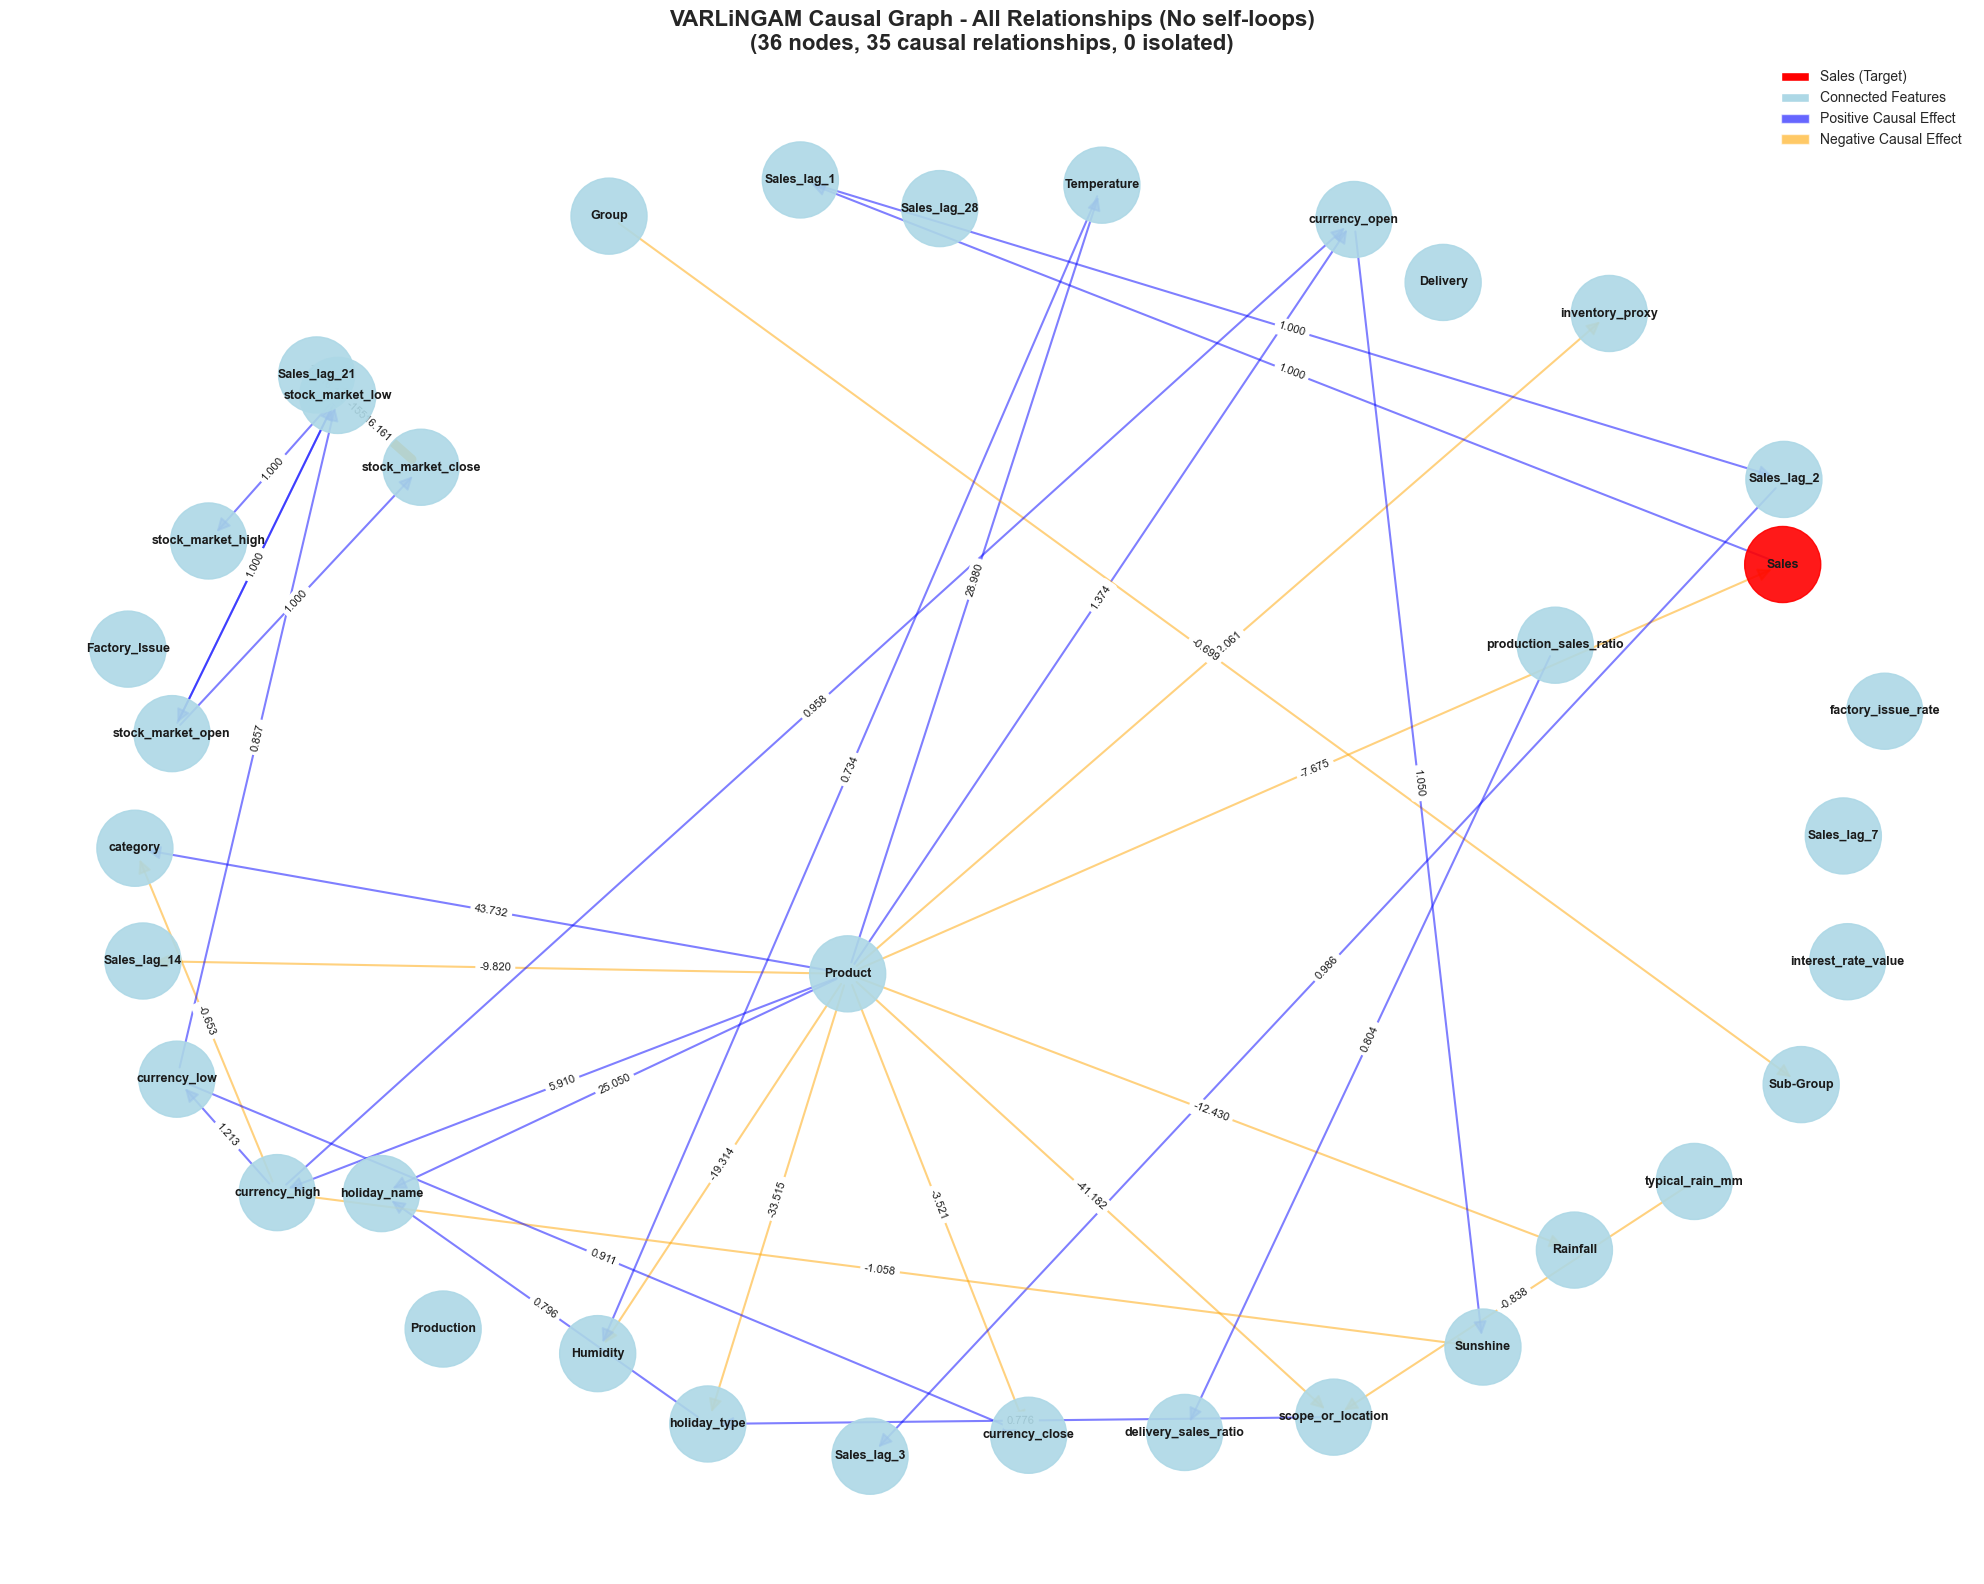

✓ Visualization created
  Edge width range: 1.50 to 6.50

✓ VARLiNGAM ANALYSIS COMPLETE
  Total features analyzed: 36
  Features with relationships: 36
  Isolated features: 0
  Self-loops removed: 17


In [74]:
def create_varlingam_causal_graph(df_processed, target_col='Sales', exclude_cols=['Date'], max_lag=1, prune_threshold=0.05,
                                  node_fontsize=9, edge_label_fontsize=8, node_size=3000, edge_width_multiplier=5,
                                  min_edge_width=1.5, show_all_relationships=True, top_n_relationships=50,
                                  remove_multicollinear=True, correlation_threshold=0.95, remove_self_loops=True):
    """
    Generate a causality graph using VARLiNGAM on the processed dataset.
    Since the data already contains lagged features (e.g., Sales_lag_1, Sales_lag_2),
    we use max_lag=1 to avoid VARLiNGAM creating additional lags.
    
    Parameters:
    -----------
    df_processed : pd.DataFrame
        Processed dataframe with features (should already include lagged features)
    target_col : str
        Target variable name (default: 'Sales')
    exclude_cols : list
        Columns to exclude from analysis (default: ['Date'])
    max_lag : int
        Maximum time lag for VAR model (default: 1, since lags are already in data)
    prune_threshold : float
        Threshold for pruning weak causal relationships (default: 0.05)
    node_fontsize : int
        Font size for node labels (default: 9)
    edge_label_fontsize : int
        Font size for edge labels (default: 8)
    node_size : int
        Size of nodes (default: 3000)
    edge_width_multiplier : float
        Multiplier for edge width (default: 5)
    min_edge_width : float
        Minimum width for edges to ensure visibility (default: 1.5)
    show_all_relationships : bool
        If True, show all causal relationships. If False, only show target-related ones (default: True)
    top_n_relationships : int
        Maximum number of relationships to visualize (default: 50)
    remove_multicollinear : bool
        If True, remove highly correlated features. If False, keep them (default: True)
    correlation_threshold : float
        Threshold for identifying highly correlated features (default: 0.95)
    remove_self_loops : bool
        If True, exclude self-loop edges (A -> A). If False, include them (default: True)
        
    Returns:
    --------
    dict : Dictionary containing model results, adjacency matrices, and causal relationships
    """
    import numpy as np
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    
    try:
        from lingam import VARLiNGAM
        import networkx as nx
        import matplotlib.pyplot as plt
    except ImportError:
        print("Required packages not installed. Install with:")
        print("  pip install lingam networkx")
        return None
    
    print("="*80)
    print("VARLINGAM CAUSAL GRAPH GENERATION")
    print("="*80)
    print(f"ℹ Note: Using max_lag={max_lag} since lagged features are already in the dataset")
    print(f"ℹ Remove self-loops: {remove_self_loops}")
    print("="*80)
    
    # Prepare data
    df_analysis = df_processed.copy()
    
    # Remove excluded columns
    cols_to_drop = [col for col in exclude_cols if col in df_analysis.columns]
    if cols_to_drop:
        df_analysis = df_analysis.drop(columns=cols_to_drop)
        print(f"✓ Removed columns: {cols_to_drop}")
    
    # Ensure target column exists
    if target_col not in df_analysis.columns:
        print(f"❌ Error: Target column '{target_col}' not found in dataframe")
        return None
    
    # Handle missing values
    if df_analysis.isnull().any().any():
        print(f"⚠ Warning: Found {df_analysis.isnull().sum().sum()} missing values. Filling with 0...")
        df_analysis = df_analysis.fillna(0)
    
    # Replace inf values
    df_analysis = df_analysis.replace([np.inf, -np.inf], 0)
    
    # Remove constant columns (zero variance)
    constant_cols = df_analysis.columns[df_analysis.std() == 0].tolist()
    if constant_cols:
        print(f"⚠ Warning: Removing {len(constant_cols)} constant columns: {constant_cols[:5]}...")
        df_analysis = df_analysis.drop(columns=constant_cols)
    
    # Check for multicollinearity
    print(f"\n{'='*80}")
    print("✓ Checking for multicollinearity...")
    print(f"{'='*80}")
    print(f"  Correlation threshold: {correlation_threshold}")
    print(f"  Remove multicollinear features: {remove_multicollinear}")
    
    corr_matrix = df_analysis.corr().abs()
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features with correlation greater than threshold
    high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > correlation_threshold)]
    
    if high_corr_features:
        # Keep target column if it's in the list
        high_corr_features_to_remove = [f for f in high_corr_features if f != target_col]
        
        print(f"\n  Found {len(high_corr_features_to_remove)} highly correlated features (correlation > {correlation_threshold}):")
        for i, feat in enumerate(high_corr_features_to_remove, 1):
            # Find what it's correlated with
            corr_pairs = upper_triangle[feat][upper_triangle[feat] > correlation_threshold]
            if len(corr_pairs) > 0:
                correlated_with = corr_pairs.index[0]
                corr_value = corr_pairs.values[0]
                print(f"    {i}. {feat} <-> {correlated_with} (correlation: {corr_value:.4f})")
        
        if remove_multicollinear:
            df_analysis = df_analysis.drop(columns=high_corr_features_to_remove)
            print(f"\n  ✓ Removed {len(high_corr_features_to_remove)} highly correlated features")
            print(f"    Features removed: {high_corr_features_to_remove}")
        else:
            print(f"\n  ℹ Keeping all {len(high_corr_features_to_remove)} highly correlated features (remove_multicollinear=False)")
            print(f"    Features kept: {high_corr_features_to_remove}")
    else:
        print(f"\n  ✓ No highly correlated features found (correlation > {correlation_threshold})")
    
    print(f"\n{'='*80}")
    print(f"✓ Target variable: {target_col}")
    print(f"✓ Number of features after preprocessing: {df_analysis.shape[1]}")
    print(f"✓ Number of samples: {df_analysis.shape[0]}")
    print(f"✓ Max lag: {max_lag}")
    
    # Store ALL feature names (this is important - all nodes to be included)
    feature_names = df_analysis.columns.tolist()
    all_features = feature_names.copy()  # Keep a copy of ALL features
    
    # Standardize the data to improve numerical stability
    print("\n✓ Standardizing data for numerical stability...")
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(df_analysis)
    
    # Add small regularization to diagonal to improve positive definiteness
    data_scaled = data_scaled + np.random.normal(0, 1e-6, data_scaled.shape)
    
    print(f"\n{'='*80}")
    print("FITTING VARLINGAM MODEL")
    print(f"{'='*80}")
    
    # Fit VARLiNGAM model with error handling
    try:
        model = VARLiNGAM(lags=max_lag, prune=True)
        model.fit(data_scaled)
        print("✓ VARLiNGAM model fitted successfully")
    except Exception as e:
        print(f"❌ Error fitting VARLiNGAM model: {e}")
        print("\n💡 Suggestions:")
        print("  1. Reduce the number of features")
        print("  2. Use a smaller subset of data")
        print("  3. Increase prune_threshold")
        print("  4. Set remove_multicollinear=True")
        return None
    
    # Extract causal relationships
    print(f"\n{'='*80}")
    print("EXTRACTING CAUSAL RELATIONSHIPS")
    print(f"{'='*80}")
    
    # Get adjacency matrices for each lag
    adjacency_matrices = model.adjacency_matrices_
    
    # Collect all causal relationships
    causal_relationships = []
    self_loops_count = 0
    
    for lag_idx, adj_matrix in enumerate(adjacency_matrices):
        lag = lag_idx + 1
        
        for i in range(len(feature_names)):
            for j in range(len(feature_names)):
                if abs(adj_matrix[i, j]) > prune_threshold:  # Threshold for significance
                    # Check for self-loop
                    is_self_loop = (i == j)
                    
                    if is_self_loop and remove_self_loops:
                        self_loops_count += 1
                        continue  # Skip self-loops if remove_self_loops is True
                    
                    causal_relationships.append({
                        'cause': feature_names[j],
                        'effect': feature_names[i],
                        'lag': lag,
                        'coefficient': float(adj_matrix[i, j]),
                        'abs_coefficient': float(abs(adj_matrix[i, j])),
                        'is_self_loop': is_self_loop
                    })
    
    if remove_self_loops and self_loops_count > 0:
        print(f"✓ Removed {self_loops_count} self-loop relationships")
    elif not remove_self_loops and self_loops_count > 0:
        print(f"ℹ Included {self_loops_count} self-loop relationships")
    
    # Create DataFrame of causal relationships
    df_causal = pd.DataFrame(causal_relationships)
    
    if len(df_causal) > 0:
        df_causal = df_causal.sort_values('abs_coefficient', ascending=False)
        print(f"\n✓ Found {len(df_causal)} total causal relationships")
        
        # Count self-loops in final relationships
        self_loops_in_data = df_causal['is_self_loop'].sum() if 'is_self_loop' in df_causal.columns else 0
        if self_loops_in_data > 0:
            print(f"  - Including {self_loops_in_data} self-loop relationships")
        
        # Filter relationships involving target variable (exact match only)
        df_target_causes = df_causal[df_causal['effect'] == target_col].copy()
        df_target_effects = df_causal[df_causal['cause'] == target_col].copy()
        
        # Relationships between features (not involving target)
        df_feature_relationships = df_causal[
            (df_causal['effect'] != target_col) & (df_causal['cause'] != target_col)
        ].copy()
        
        print(f"\n{'='*80}")
        print(f"CAUSAL RELATIONSHIPS BREAKDOWN")
        print(f"{'='*80}")
        print(f"\nFactors influencing {target_col}: {len(df_target_causes)}")
        if len(df_target_causes) > 0:
            print("\nTop 10 strongest causes of Sales:")
            print(df_target_causes.head(10)[['cause', 'lag', 'coefficient']].to_string(index=False))
        
        print(f"\n{target_col} influences: {len(df_target_effects)}")
        if len(df_target_effects) > 0:
            print("\nTop 10 strongest effects from Sales:")
            print(df_target_effects.head(10)[['effect', 'lag', 'coefficient']].to_string(index=False))
        
        print(f"\nFeature-to-feature relationships (not involving {target_col}): {len(df_feature_relationships)}")
        if len(df_feature_relationships) > 0:
            print("\nTop 10 strongest feature-to-feature relationships:")
            print(df_feature_relationships.head(10)[['cause', 'effect', 'lag', 'coefficient']].to_string(index=False))
    else:
        print("⚠ Warning: No significant causal relationships found")
        df_target_causes = pd.DataFrame()
        df_target_effects = pd.DataFrame()
        df_feature_relationships = pd.DataFrame()
    
    # Identify features with no relationships
    features_with_edges = set()
    if len(df_causal) > 0:
        features_with_edges = set(df_causal['cause'].unique()) | set(df_causal['effect'].unique())
    
    isolated_features = set(all_features) - features_with_edges
    if isolated_features:
        print(f"\n⚠ Isolated features (no causal relationships): {len(isolated_features)}")
        print(f"  {list(isolated_features)[:10]}{'...' if len(isolated_features) > 10 else ''}")
    
    # Create visualization
    print(f"\n{'='*80}")
    print("CREATING VISUALIZATION")
    print(f"{'='*80}")
    
    # Select relationships to visualize
    if show_all_relationships and len(df_causal) > 0:
        # Show all relationships (top N by strength)
        df_viz = df_causal.head(top_n_relationships)
        print(f"✓ Visualizing top {len(df_viz)} relationships (from {len(df_causal)} total)")
    elif len(df_causal) > 0:
        # Show only target-related relationships
        df_viz = df_causal[
            (df_causal['effect'] == target_col) | (df_causal['cause'] == target_col)
        ].head(top_n_relationships)
        print(f"✓ Visualizing {len(df_viz)} target-related relationships")
    else:
        df_viz = pd.DataFrame()
        print("⚠ No relationships to visualize")
    
    fig, ax = plt.subplots(1, 1, figsize=(20, 16))
    
    # Create directed graph
    G = nx.DiGraph()
    
    # Add ALL features as nodes (IMPORTANT: This ensures all nodes are included)
    for feature in all_features:
        G.add_node(feature)
    
    print(f"✓ Added all {len(all_features)} features as nodes")
    
    # Add edges from relationships
    if len(df_viz) > 0:
        for _, row in df_viz.iterrows():
            cause = row['cause']
            effect = row['effect']
            weight = row['abs_coefficient']
            lag = row['lag']
            
            G.add_edge(cause, effect, weight=weight, coef=row['coefficient'], lag=lag)
    
    print(f"✓ Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
    
    # Layout - use spring layout for better visualization of complex relationships
    # Isolated nodes will be positioned by the layout algorithm
    pos = nx.spring_layout(G, k=3, iterations=100, seed=42)
    
    # Draw nodes - only exact match with target_col is red, isolated nodes in gray
    node_colors = []
    for node in G.nodes():
        if node == target_col:
            node_colors.append('red')
        elif node in isolated_features:
            node_colors.append('lightgray')  # Gray for isolated nodes
        else:
            node_colors.append('lightblue')
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size, alpha=0.9, ax=ax)
    
    # Draw edges with varying thickness and color - improved visibility
    if G.number_of_edges() > 0:
        edges = G.edges()
        weights = [G[u][v]['weight'] for u, v in edges]
        max_weight = max(weights) if weights else 1
        min_weight = min(weights) if weights else 0
        
        for (u, v), weight in zip(edges, weights):
            coef = G[u][v]['coef']
            
            # Normalize weight to range [min_edge_width, min_edge_width + edge_width_multiplier]
            # This ensures minimum visibility while maintaining relative differences
            normalized_weight = (weight - min_weight) / (max_weight - min_weight) if max_weight > min_weight else 0.5
            width = min_edge_width + (normalized_weight * edge_width_multiplier)
            
            # Use blue/orange based on coefficient sign
            if coef > 0:
                color = 'blue'  # Positive relationships in blue
                alpha = 0.5 + (normalized_weight * 0.5)  # Alpha between 0.5 and 1.0
            else:
                color = 'orange'  # Negative relationships in orange
                alpha = 0.5 + (normalized_weight * 0.5)  # Alpha between 0.5 and 1.0
            
            nx.draw_networkx_edges(G, pos, [(u, v)], width=width, 
                                  edge_color=color, alpha=alpha, 
                                  arrows=True, arrowsize=20, ax=ax)
        
        # Add edge labels
        edge_labels = {(u, v): f"{G[u][v]['coef']:.3f}" for u, v in G.edges()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=edge_label_fontsize, ax=ax)
    
    # Draw labels for all nodes
    nx.draw_networkx_labels(G, pos, font_size=node_fontsize, font_weight='bold', ax=ax)
    
    title_suffix = "All Relationships" if show_all_relationships else "Target-Related Relationships"
    selfloop_text = "(No self-loops)" if remove_self_loops else "(Including self-loops)"
    ax.set_title(f'VARLiNGAM Causal Graph - {title_suffix} {selfloop_text}\n({G.number_of_nodes()} nodes, {G.number_of_edges()} causal relationships, {len(isolated_features)} isolated)', 
                fontsize=16, fontweight='bold')
    ax.axis('off')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', label=f'{target_col} (Target)'),
        Patch(facecolor='lightblue', label='Connected Features'),
    ]
    if isolated_features:
        legend_elements.append(Patch(facecolor='lightgray', label='Isolated Features (No Relationships)'))
    if G.number_of_edges() > 0:
        legend_elements.extend([
            Patch(facecolor='blue', alpha=0.6, label='Positive Causal Effect'),
            Patch(facecolor='orange', alpha=0.6, label='Negative Causal Effect')
        ])
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    print(f"✓ Visualization created")
    if G.number_of_edges() > 0:
        print(f"  Edge width range: {min_edge_width:.2f} to {min_edge_width + edge_width_multiplier:.2f}")
    
    # Return results
    results = {
        'model': model,
        'adjacency_matrices': adjacency_matrices,
        'feature_names': all_features,  # All features included
        'all_features': all_features,  # Explicitly include all features
        'isolated_features': list(isolated_features),  # Features with no relationships
        'connected_features': list(features_with_edges),  # Features with relationships
        'causal_relationships': df_causal if len(df_causal) > 0 else None,
        'target_causes': df_target_causes if len(df_target_causes) > 0 else None,
        'target_effects': df_target_effects if len(df_target_effects) > 0 else None,
        'feature_relationships': df_feature_relationships if len(df_feature_relationships) > 0 else None,
        'max_lag': max_lag,
        'n_features': len(all_features),
        'n_samples': len(data_scaled),
        'n_isolated_features': len(isolated_features),
        'n_connected_features': len(features_with_edges),
        'self_loops_removed': self_loops_count if remove_self_loops else 0
    }
    
    print(f"\n{'='*80}")
    print("✓ VARLiNGAM ANALYSIS COMPLETE")
    print(f"{'='*80}")
    print(f"  Total features analyzed: {len(all_features)}")
    print(f"  Features with relationships: {len(features_with_edges)}")
    print(f"  Isolated features: {len(isolated_features)}")
    if remove_self_loops:
        print(f"  Self-loops removed: {self_loops_count}")
    
    return results



# Example usage - Remove multicollinear features (default)
# varlingam_results = create_varlingam_causal_graph(
#     df_processed, 
#     target_col='Sales', 
#     exclude_cols=['Date', 'Station'],
#     max_lag=1,
#     prune_threshold=0.05,
#     node_fontsize=9,
#     edge_label_fontsize=8,
#     node_size=3000,
#     edge_width_multiplier=5,
#     min_edge_width=1.5,
#     show_all_relationships=True,
#     top_n_relationships=50,
#     remove_multicollinear=True,  # Set to True to remove, False to keep
#     correlation_threshold=None,   # Threshold for identifying high correlation
#     remove_self_loops=True
# )


# varlingam_results = create_varlingam_causal_graph(
#     df_processed, 
#     target_col='Sales', 
#     exclude_cols=['Date', 'Station'],
#     max_lag=1,
#     prune_threshold=0.05,
#     node_fontsize=9,
#     edge_label_fontsize=8,
#     node_size=3000,
#     edge_width_multiplier=5,
#     min_edge_width=1.5,
#     show_all_relationships=True,
#     top_n_relationships=50,
#     remove_multicollinear=True,  # Set to True to remove, False to keep
#     correlation_threshold=0.95,   # Threshold for identifying high correlation
#     remove_self_loops=True
# )


# Example: Keep multicollinear features
varlingam_results = create_varlingam_causal_graph(
    df_processed, 
    target_col='Sales', 
    exclude_cols=['Date', 'Station'],
    max_lag=1,
    remove_multicollinear=False,  # Keep highly correlated features
    correlation_threshold=0.95,
    remove_self_loops=True
)


In [75]:
varlingam_results["causal_relationships"]

,cause,effect,lag,coefficient,abs_coefficient,is_self_loop
268,stock_market_low,Sales_lag_21,2,15516.185768,15516.185768,False
269,stock_market_close,Sales_lag_21,2,-15516.161091,15516.161091,False
212,Product,category,2,-43.737085,43.737085,False
44,Product,category,1,43.732245,43.732245,False
226,Product,scope_or_location,2,41.185371,41.185371,False
...,...,...,...,...,...,...
302,currency_high,currency_open,2,0.051616,0.051616,False
130,Sunshine,stock_market_low,1,-0.051544,0.051544,False
304,typical_rain_mm,currency_high,2,-0.051332,0.051332,False
246,typical_rain_mm,Sales_lag_7,2,0.050453,0.050453,False


In [76]:
len(df_processed.columns)

38

### Train - Test Split

In [77]:
# Keep ALL data - no dropping
df_processed.drop(columns=["Station"], inplace=True)
df_clean = df_processed.copy()

# Split based on date only
min_date = df_clean['Date'].min()  # 2023-01-01
max_date = df_clean['Date'].max()  # 2023-08-09
split_date = max_date - timedelta(days=TEST_SIZE_DAYS - 1)

# Split ALL data
train_df = df_clean[df_clean['Date'] < split_date].copy()
test_df = df_clean[df_clean['Date'] >= split_date].copy()

# For target columns: fill NaN with a special value or use masking
target_cols = [col for col in df_clean.columns if col.startswith('target_')]

# # Option 3a: Fill NaN targets with -1 (will be ignored during training)
# for col in target_cols:
#     train_df[col] = train_df[col].fillna(-1)
#     test_df[col] = test_df[col].fillna(-1)

# Option 3b: Create a mask to identify valid targets
# train_df['has_valid_target'] = ~train_df[f'target_{max(FORECAST_HORIZONS)}d_sum'].isna()

print(f"{'='*80}")
print(f"TRAIN-TEST SPLIT (ZERO Data Loss)")
print(f"{'='*80}")
print(f"\nData Range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Split Date: {split_date.strftime('%Y-%m-%d')}")

print(f"\nTrain Set:")
print(f"  - Date range: {train_df['Date'].min().strftime('%Y-%m-%d')} to {train_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"  - Shape: {train_df.shape}")
print(f"  - ALL {len(train_df):,} rows kept")

print(f"\nTest Set:")
print(f"  - Date range: {test_df['Date'].min().strftime('%Y-%m-%d')} to {test_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"  - Shape: {test_df.shape}")
print(f"  - ALL {len(test_df):,} rows kept")

print(f"\nTotal: {len(df_clean):,} samples (100% data usage)")
print(f"Zero rows dropped!")
print(f"\n{'='*80}")

TRAIN-TEST SPLIT (ZERO Data Loss)

Data Range: 2023-01-01 to 2023-08-09
Split Date: 2023-07-11

Train Set:
  - Date range: 2023-01-01 to 2023-07-10
  - Shape: (7831, 37)
  - ALL 7,831 rows kept

Test Set:
  - Date range: 2023-07-11 to 2023-08-09
  - Shape: (1230, 37)
  - ALL 1,230 rows kept

Total: 9,061 samples (100% data usage)
Zero rows dropped!



In [78]:
train_df.shape

(7831, 37)

In [34]:
test_df.shape

(1230, 37)

<br> <br> <br>

### 8. Prepare ML-Ready Datasets

In [80]:
# Define feature columns (exclude metadata and target columns)
# exclude_cols = ['Date', 'Product', 'Sub-Group', 'has_valid_target'] + [col for col in df_clean.columns if col.startswith('target_')]
# exclude_cols = ['Date', "Sales"]  + [col for col in df_clean.columns if col.startswith('target_')] # We dont need target becuase we have already got Sales_lag_1, 2, ...
exclude_cols = ["Sales"]  + [col for col in df_clean.columns if col.startswith('target_')] # We dont need target becuase we have already got Sales_lag_1, 2, ...
feature_cols = [col for col in df_clean.columns if col not in exclude_cols]

# Fill remaining NaN with 0 (from lag features at the beginning)
train_df[feature_cols] = train_df[feature_cols].fillna(0)
test_df[feature_cols] = test_df[feature_cols].fillna(0)

print(f"Feature columns ({len(feature_cols)}):")
print(f"  First 10: {feature_cols[:10]}")
print(f"  Last 10: {feature_cols[-10:]}")

print(f"\nTarget columns ({len([col for col in df_clean.columns if col.startswith('target_')])}):")
print(f"  {[col for col in df_clean.columns if col.startswith('target_')]}")

# Prepare X and y using target_1d_sum
print(f"\n{'='*80}")
print(f"ML-READY DATASETS PREPARED (Using target_1d_sum)")
print(f"{'='*80}")

# Use target_1d_sum for training/testing
# target_col = 'target_1d_sum'
target_col = 'Sales'

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"\nTarget: {target_col}")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_test: {X_test.shape}, y_test: {y_test.shape}")


# Check for -1 values (NaN replacements)
nan_count_train = (y_train == -1).sum()
nan_count_test = (y_test == -1).sum()
print(f"\n  NaN values (marked as -1):")
print(f"    Train: {nan_count_train} ({nan_count_train/len(y_train)*100:.1f}%)")
print(f"    Test: {nan_count_test} ({nan_count_test/len(y_test)*100:.1f}%)")

print(f"\n{'='*80}")
print(f"✓ Feature engineering pipeline complete!")
print(f"  Ready to train with: X_train, y_train, X_test, y_test")
print(f"{'='*80}")

Feature columns (36):
  First 10: ['Date', 'Product', 'Production', 'Factory_Issue', 'Delivery', 'Group', 'Sub-Group', 'holiday_type', 'holiday_name', 'Rainfall']
  Last 10: ['inventory_proxy', 'currency_open', 'currency_high', 'currency_low', 'currency_close', 'interest_rate_value', 'stock_market_open', 'stock_market_high', 'stock_market_low', 'stock_market_close']

Target columns (0):
  []

ML-READY DATASETS PREPARED (Using target_1d_sum)

Target: Sales
  X_train: (7831, 36), y_train: (7831,)
  X_test: (1230, 36), y_test: (1230,)

  NaN values (marked as -1):
    Train: 0 (0.0%)
    Test: 0 (0.0%)

✓ Feature engineering pipeline complete!
  Ready to train with: X_train, y_train, X_test, y_test


In [81]:
X_train

,Date,Product,Production,Factory_Issue,Delivery,Group,Sub-Group,holiday_type,holiday_name,Rainfall,Sunshine,Humidity,Temperature,category,scope_or_location,typical_rain_mm,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,production_sales_ratio,delivery_sales_ratio,factory_issue_rate,inventory_proxy,currency_open,currency_high,currency_low,currency_close,interest_rate_value,stock_market_open,stock_market_high,stock_market_low,stock_market_close
0,2023-01-01,0,0.079538,0.049447,0.038181,0,0,2,13,0.000000,0.380952,0.777778,0.222222,7,1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.162403e-11,2.315082e-11,7.768701e-11,0.621192,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
1,2023-01-02,0,0.079538,0.087679,0.125128,0,0,2,13,0.000000,0.523810,0.619048,0.280193,4,6,0.0,0.090322,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.027763e-10,1.873363e-10,1.377543e-10,0.625206,0.000000,0.415254,0.000000,0.434426,0.0,0.000000,0.000000,0.000000,0.000000
2,2023-01-03,0,0.106050,0.151093,0.119652,0,0,2,13,0.000000,0.000000,0.873016,0.140097,4,6,0.0,0.036580,0.090322,0.000000,0.000000,0.000000,0.000000,0.000000,6.226224e-11,8.139172e-11,1.780394e-10,0.621892,0.447154,0.423729,0.064024,0.008197,0.0,0.037881,0.037881,0.037881,0.037881
3,2023-01-04,0,0.106050,0.115461,0.131717,0,0,2,13,0.000000,0.000000,0.936508,0.072464,4,6,0.0,0.080510,0.036580,0.090322,0.000000,0.000000,0.000000,0.000000,1.611646e-10,2.319240e-10,1.360524e-10,0.632069,0.447154,0.423729,0.067073,0.000000,0.0,0.130579,0.130579,0.130579,0.130579
4,2023-01-05,0,0.106050,0.056074,0.039736,0,0,2,13,0.000000,0.123810,0.857143,0.091787,4,6,0.0,0.031103,0.080510,0.036580,0.000000,0.000000,0.000000,0.000000,4.184577e-11,1.816668e-11,6.607400e-11,0.618030,0.447154,0.423729,0.100610,0.032787,0.0,0.084837,0.084837,0.084837,0.084837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9026,2023-07-06,40,0.063630,0.059999,0.123994,4,18,2,13,0.026087,0.476190,0.777778,0.768116,4,6,0.0,0.064955,0.093672,0.093501,0.000000,0.214010,0.132440,0.081946,2.645115e-11,5.972132e-11,1.178320e-10,0.566745,0.918699,0.915254,0.875000,0.865574,0.0,0.827846,0.827846,0.827846,0.827846
9027,2023-07-07,40,0.000000,0.049192,0.062861,4,18,2,13,0.095652,0.495238,0.777778,0.782609,4,6,0.0,0.113706,0.064955,0.093672,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.007008e-01,1.159298e-01,0.566745,0.866667,0.861017,0.875000,0.865574,0.0,0.849056,0.849056,0.849056,0.849056
9028,2023-07-08,40,0.000000,0.041902,0.101528,4,18,2,13,0.095652,0.857143,0.666667,0.835749,4,6,0.0,0.000000,0.113706,0.064955,0.000000,0.023965,0.007419,0.024033,0.000000e+00,3.170445e-10,9.875060e-02,0.561957,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
9029,2023-07-09,40,0.079856,0.081817,0.109309,4,18,2,13,0.000000,0.161905,0.761905,0.816425,4,6,0.0,0.017538,0.000000,0.113706,0.084202,0.173270,0.174280,0.149226,2.221093e-11,3.522608e-11,1.280318e-10,0.529613,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000


In [37]:
y_train

0       0.090322
1       0.036580
2       0.080510
3       0.031103
4       0.119791
          ...   
9026    0.113706
9027    0.000000
9028    0.017538
9029    0.169943
9030    0.112509
Name: Sales, Length: 7831, dtype: float64

In [38]:
X_test

,Date,Product,Production,Factory_Issue,Delivery,Group,Sub-Group,holiday_type,holiday_name,Rainfall,Sunshine,Humidity,Temperature,category,scope_or_location,typical_rain_mm,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,production_sales_ratio,delivery_sales_ratio,factory_issue_rate,inventory_proxy,currency_open,currency_high,currency_low,currency_close,interest_rate_value,stock_market_open,stock_market_high,stock_market_low,stock_market_close
191,2023-07-11,0,0.053025,0.074017,0.057634,0,0,2,13,0.026087,0.000000,0.698413,0.821256,4,6,0.000000,0.040648,0.071895,0.002373,0.031725,0.003897,0.023931,0.001197,3.093409e-10,3.895626e-10,1.744354e-10,0.589769,0.918699,0.915254,0.899390,0.891803,0.0,0.791970,0.791970,0.791970,0.791970
192,2023-07-12,0,0.053025,0.037468,0.025328,0,0,2,13,0.000000,0.009524,0.698413,0.811594,4,6,0.000000,0.008102,0.040648,0.071895,0.013777,0.000000,0.024785,0.034358,1.446031e-10,8.002850e-11,8.829889e-11,0.594371,0.918699,0.915254,0.896341,0.888525,0.0,0.838398,0.838398,0.838398,0.838398
193,2023-07-13,0,0.042420,0.015803,0.027650,0,0,2,13,0.008696,0.371429,0.714286,0.816425,4,6,0.000000,0.017333,0.008102,0.040648,0.042665,0.000000,0.034118,0.040648,5.617914e-11,4.242768e-11,4.655214e-11,0.592093,0.918699,0.915254,0.896341,0.888525,0.0,0.861137,0.861137,0.861137,0.861137
194,2023-07-14,0,0.042420,0.042463,0.029540,0,0,2,13,0.008696,0.038095,0.761905,0.801932,4,6,0.000000,0.035691,0.017333,0.008102,0.000000,0.000000,0.000000,0.000000,5.865103e-02,4.732244e-02,1.250901e-10,0.599561,0.889431,0.884746,0.896341,0.888525,0.0,1.000000,1.000000,1.000000,1.000000
195,2023-07-15,0,0.018559,0.021155,0.032835,0,0,2,13,0.052174,0.600000,0.682540,0.787440,4,6,0.000000,0.000000,0.035691,0.017333,0.002373,0.000000,0.000239,0.001880,8.727831e-10,1.789106e-09,1.424453e-10,0.602554,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9056,2023-08-05,40,0.063789,0.087118,0.079765,4,18,2,13,0.478261,0.542857,0.777778,0.777778,8,0,0.845333,0.000000,0.125432,0.079826,0.000000,0.006290,0.008068,0.017538,8.091420e-10,1.172287e-09,1.706650e-10,0.594925,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
9057,2023-08-06,40,0.053025,0.088444,0.063671,4,18,2,13,0.043478,0.476190,0.936508,0.700483,4,6,0.000000,0.003726,0.000000,0.125432,0.130252,0.144986,0.142525,0.169943,2.530679e-11,3.520830e-11,2.084334e-10,0.577218,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
9058,2023-08-07,40,0.106050,0.085385,0.135335,4,18,2,13,0.156522,0.400000,1.000000,0.681159,4,6,0.000000,0.099039,0.003726,0.000000,0.083895,0.079519,0.075690,0.112509,6.147906e-11,9.090180e-11,1.006127e-10,0.573624,1.000000,1.000000,0.989329,0.988525,0.0,0.642503,0.642503,0.642503,0.642503
9059,2023-08-08,40,0.054298,0.022684,0.027002,4,18,2,13,0.469565,0.676190,0.936508,0.676329,4,6,0.000000,0.081536,0.099039,0.003726,0.086424,0.047520,0.061673,0.072613,7.507331e-02,4.325634e-02,5.220691e-11,0.583183,1.000000,1.000000,0.939024,1.000000,0.0,0.726443,0.726443,0.726443,0.726443


In [39]:
y_test

191     0.008102
192     0.017333
193     0.035691
194     0.000000
195     0.001005
          ...   
9056    0.003726
9057    0.099039
9058    0.081536
9059    0.000000
9060    0.000000
Name: Sales, Length: 1230, dtype: float64

<br> <br> <br>


Here is the updated table with a description column:

| Feature Name | Source DataFrame | Dataset Name | Description |
|---|---|---|---|
| `Date` | `df_base` ← `df_temporal_sales_order` | SupplyGraph — Sales Order | Calendar date of the observation |
| `Product` | `df_sales_long` ← `df_temporal_sales_order` | SupplyGraph — Sales Order | Product identifier (label-encoded) |
| `Production` | `df_production_long` ← `df_temporal_production` | SupplyGraph — Production | Daily units produced per product |
| `Factory_Issue` | `df_factory_issue_long` ← `df_temporal_factory_issue` | SupplyGraph — Factory Issue | Daily units issued from factory per product |
| `Delivery` | `df_delivery_long` ← `df_temporal_delivery_to_distributor` | SupplyGraph — Delivery To Distributor | Daily units delivered to distributors per product |
| `Group` | `df_meta_filtered` ← `df_nodes_productgroup_and_subgroup` | SupplyGraph — Product Group & Subgroup Nodes | Product group classification (label-encoded) |
| `Sub-Group` | `df_meta_filtered` ← `df_nodes_productgroup_and_subgroup` | SupplyGraph — Product Group & Subgroup Nodes | Product sub-group classification (label-encoded) |
| `holiday_type` | `df_holidays_clean` ← `df_holidays` | In-notebook Bangladesh holidays | Type of holiday (e.g., National Holiday; label-encoded) |
| `holiday_name` | `df_holidays_clean` ← `df_holidays` | In-notebook Bangladesh holidays | Name of the holiday on that date, or "no_holiday" (label-encoded) |
| `Rainfall` | `df_weather_dhaka` ← `df_weather` | Weather — Dhaka Station | Daily rainfall in mm at the Dhaka meteorological station |
| `Sunshine` | `df_weather_dhaka` ← `df_weather` | Weather — Dhaka Station | Daily sunshine duration (hours) at the Dhaka meteorological station |
| `Humidity` | `df_weather_dhaka` ← `df_weather` | Weather — Dhaka Station | Daily relative humidity (%) at the Dhaka meteorological station |
| `Temperature` | `df_weather_dhaka` ← `df_weather` | Weather — Dhaka Station | Daily mean temperature (°C) at the Dhaka meteorological station |
| `category` | `df_events_clean` ← `df_events` | BangladeshEvents — event.csv | Event category on that date (e.g., cultural, religious; label-encoded) |
| `scope_or_location` | `df_events_clean` ← `df_events` | BangladeshEvents — event.csv | Geographic scope or location of the event (label-encoded) |
| `typical_rain_mm` | `df_events_clean` ← `df_events` | BangladeshEvents — event.csv | Typical rainfall (mm) associated with the event's climate context |
| `Sales_lag_1` | `df_features` (engineered) | Derived from Sales | Sales quantity 1 day prior (lag-1 autoregressive feature) |
| `Sales_lag_2` | `df_features` (engineered) | Derived from Sales | Sales quantity 2 days prior |
| `Sales_lag_3` | `df_features` (engineered) | Derived from Sales | Sales quantity 3 days prior |
| `Sales_lag_7` | `df_features` (engineered) | Derived from Sales | Sales quantity 7 days prior (same weekday, one week ago) |
| `Sales_lag_14` | `df_features` (engineered) | Derived from Sales | Sales quantity 14 days prior (two weeks ago) |
| `Sales_lag_21` | `df_features` (engineered) | Derived from Sales | Sales quantity 21 days prior (three weeks ago) |
| `Sales_lag_28` | `df_features` (engineered) | Derived from Sales | Sales quantity 28 days prior (four weeks ago) |
| `production_sales_ratio` | `df_features` (engineered) | Derived from Production & Sales | Ratio of daily production to daily sales; proxy for supply surplus/deficit |
| `delivery_sales_ratio` | `df_features` (engineered) | Derived from Delivery & Sales | Ratio of daily delivery to daily sales; proxy for distribution efficiency |
| `factory_issue_rate` | `df_features` (engineered) | Derived from Factory Issue & Production | Ratio of factory issues to production; proxy for factory defect or dispatch rate |
| `inventory_proxy` | `df_features` (engineered) | Derived from Production & Sales | Cumulative sum of (Production − Sales) per product; proxy for stock level |
| `currency_open` | `df_trading_economics_currency` | TradingEconomics — currency.csv | BDT/USD exchange rate at market open |
| `currency_high` | `df_trading_economics_currency` | TradingEconomics — currency.csv | Highest BDT/USD exchange rate during the trading day |
| `currency_low` | `df_trading_economics_currency` | TradingEconomics — currency.csv | Lowest BDT/USD exchange rate during the trading day |
| `currency_close` | `df_trading_economics_currency` | TradingEconomics — currency.csv | BDT/USD exchange rate at market close |
| `interest_rate_value` | `df_trading_economics_interest_rate` | TradingEconomics — Interest_Rate.csv | Bangladesh central bank policy interest rate (%) |
| `stock_market_open` | `df_trading_economics_stock_market` | TradingEconomics — stock_market.csv | Dhaka stock market index value at open |
| `stock_market_high` | `df_trading_economics_stock_market` | TradingEconomics — stock_market.csv | Highest Dhaka stock market index value during the trading day |
| `stock_market_low` | `df_trading_economics_stock_market` | TradingEconomics — stock_market.csv | Lowest Dhaka stock market index value during the trading day |
| `stock_market_close` | `df_trading_economics_stock_market` | TradingEconomics — stock_market.csv | Dhaka stock market index value at close |

In [94]:
X_train["interest_rate_value"]

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
9026    0.0
9027    0.0
9028    0.0
9029    0.0
9030    0.0
Name: interest_rate_value, Length: 7831, dtype: float64

<br> <br> <br>

## Defining ML Metrics

In [40]:
def calculate_metrics(y_true, y_pred, model_name="Model", y_train=None):
    """Calculate comprehensive evaluation metrics including MASE"""
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    
    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    mae = mean_absolute_error(y_true_clean, y_pred_clean)
    r2 = r2_score(y_true_clean, y_pred_clean)
    
    # MAPE calculation
    mask_nonzero = y_true_clean != 0
    if mask_nonzero.sum() > 0:
        mape = np.mean(np.abs((y_true_clean[mask_nonzero] - y_pred_clean[mask_nonzero]) / y_true_clean[mask_nonzero])) * 100
    else:
        mape = np.nan
    
    # MASE calculation
    # MASE = MAE / MAE_naive, where naive forecast is y_{t-1}
    if y_train is not None and len(y_train) > 1:
        # Use training data for scaling factor (preferred method)
        y_train_clean = y_train[~np.isnan(y_train)]
        naive_errors = np.abs(np.diff(y_train_clean))
        scale = np.mean(naive_errors)
    elif len(y_true_clean) > 1:
        # Fallback: use test data for scaling factor
        naive_errors = np.abs(np.diff(y_true_clean))
        scale = np.mean(naive_errors)
    else:
        scale = np.nan
    
    if scale > 0 and not np.isnan(scale):
        mase = mae / scale
    else:
        mase = np.nan
    
    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'MASE': mase,
        'R²': r2,
        'N_samples': len(y_true_clean)
    }


def print_metrics_summary(metrics_dict):
    """Print metrics in formatted way"""
    print(f"{metrics_dict['Model']:35s} | RMSE: {metrics_dict['RMSE']:>8,.0f} | MAE: {metrics_dict['MAE']:>8,.0f} | MAPE: {metrics_dict['MAPE']:>6.2f}% | MASE: {metrics_dict['MASE']:>6.3f} | R²: {metrics_dict['R²']:>6.4f}")

print("✓ Helper functions defined")

✓ Helper functions defined


<br> <br> <br>

## Training Machine Learning Models WITHOUT Trading Economics datasets

In [41]:
# Dictionary to store models and results
X_train.drop(columns=["Date"], inplace=True)
X_test.drop(columns=["Date"], inplace=True)

models = {}
predictions = {}
metrics_results = []

print("="*80)
print("TRAINING MULTIPLE MODELS")
print("="*80)

# 1. Random Forest
print("\n1. Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

models['RandomForest'] = rf_model
predictions['RandomForest'] = rf_pred

rf_metrics = calculate_metrics(y_test, rf_pred, "RandomForest", y_train=y_train)
metrics_results.append(rf_metrics)
print_metrics_summary(rf_metrics)

# 2. XGBoost
print("\n2. Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=6,
    subsample=0.8, 
    colsample_bytree=0.8, 
    min_child_weight=3,
    reg_alpha=0.1, 
    reg_lambda=1.0, 
    random_state=42,
    n_jobs=-1, 
    tree_method='hist'
)

xgb_model.fit(X_train, y_train, verbose=False)
xgb_pred = xgb_model.predict(X_test)

models['XGBoost'] = xgb_model
predictions['XGBoost'] = xgb_pred

xgb_metrics = calculate_metrics(y_test, xgb_pred, "XGBoost", y_train=y_train)
metrics_results.append(xgb_metrics)
print_metrics_summary(xgb_metrics)

# 3. LightGBM
print("\n3. Training LightGBM...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)

models['LightGBM'] = lgb_model
predictions['LightGBM'] = lgb_pred

lgb_metrics = calculate_metrics(y_test, lgb_pred, "LightGBM", y_train=y_train)
metrics_results.append(lgb_metrics)
print_metrics_summary(lgb_metrics)

# 4. CatBoost
print("\n4. Training CatBoost...")
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    subsample=0.8,
    colsample_bylevel=0.8,
    random_state=42,
    verbose=False
)

cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)

models['CatBoost'] = cat_model
predictions['CatBoost'] = cat_pred

cat_metrics = calculate_metrics(y_test, cat_pred, "CatBoost", y_train=y_train)
metrics_results.append(cat_metrics)
print_metrics_summary(cat_metrics)

# Summary comparison
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

# Create summary dataframe
summary_df = pd.DataFrame(metrics_results)
print(summary_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("BEST MODELS BY METRIC")
print("="*80)

# Define metrics and their optimization direction (lower is better or higher is better)
metric_config = {
    'RMSE': 'min',
    'MAE': 'min',
    'MAPE': 'min',
    'MASE': 'min',
    'R²': 'max',
    'SMAPE': 'min'
}

best_models = {}

for metric, direction in metric_config.items():
    if metric in summary_df.columns:
        if direction == 'min':
            best_idx = summary_df[metric].idxmin()
            best_value = summary_df[metric].min()
        else:  # max
            best_idx = summary_df[metric].idxmax()
            best_value = summary_df[metric].max()
        
        best_model_name = summary_df.loc[best_idx, 'Model']
        best_models[metric] = {
            'model': best_model_name,
            'value': best_value
        }
        
        print(f"  {metric:8s}: {best_model_name:15s} ({best_value:.4f})")

# Overall best model (by RMSE as primary metric)
overall_best = best_models['RMSE']['model']
print(f"\n✓ Overall best model (by RMSE): {overall_best}")

print("\n✓ All models trained successfully!")

TRAINING MULTIPLE MODELS

1. Training Random Forest...
RandomForest                        | RMSE:        0 | MAE:        0 | MAPE:  79.51% | MASE:  0.173 | R²: 0.9420

2. Training XGBoost...
XGBoost                             | RMSE:        0 | MAE:        0 | MAPE:  63.51% | MASE:  0.120 | R²: 0.9702

3. Training LightGBM...
LightGBM                            | RMSE:        0 | MAE:        0 | MAPE:  68.72% | MASE:  0.147 | R²: 0.9589

4. Training CatBoost...
CatBoost                            | RMSE:        0 | MAE:        0 | MAPE:  70.11% | MASE:  0.124 | R²: 0.9753

MODEL COMPARISON SUMMARY
       Model     RMSE      MAE      MAPE     MASE       R²  N_samples
RandomForest 0.013980 0.004489 79.505788 0.172671 0.942049       1230
     XGBoost 0.010022 0.003130 63.514942 0.120399 0.970218       1230
    LightGBM 0.011767 0.003825 68.724332 0.147118 0.958946       1230
    CatBoost 0.009123 0.003234 70.112484 0.124411 0.975319       1230

BEST MODELS BY METRIC
  RMSE    : CatBoost

# Note

## Why MASE needs training data

MASE is defined as:

```
MASE = MAE_model / MAE_naive
```

Where `MAE_naive` is the mean absolute error of a **naive one-step forecast** (predicting y_t = y_{t-1}).

**The standard approach** is to compute `MAE_naive` from the **training data**, not the test data. Here's why:

1. **Fair benchmark** — The naive forecast error on training data represents what a "no-skill" model would achieve on the data your model learned from

2. **Avoids data leakage** — Using test data to compute the scale mixes test information into your metric

3. **Consistent scaling** — All models are compared against the same baseline, regardless of test set characteristics

## Practical example

```python
# During training, you have:
y_train = [100, 105, 103, 110, 108, ...]  # Training targets

# During evaluation:
y_test = [...]   # Actual test values
y_pred = [...]   # Your model's predictions

# Correct usage:
metrics = calculate_metrics(y_test, y_pred, "My Model", y_train=y_train)
```

## When you might skip it

If you don't have access to `y_train` (e.g., evaluating a pre-trained model), the function falls back to using `y_true` (test data) for scaling — this is less ideal but still gives you a usable MASE value.

```python
# Fallback (no training data available):
metrics = calculate_metrics(y_test, y_pred, "My Model")
```

<br> <br> <br>

### Feature Importance

In [42]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# For explainability
try:
    import lime
    import lime.lime_tabular
    LIME_AVAILABLE = True
except ImportError:
    LIME_AVAILABLE = False
    print("LIME not available. Install with: pip install lime")

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available. Install with: pip install shap")

def explain_model_predictions(X_test, y_test, ml_model, n_samples=5, top_n=10, xai_method='SHAP'):
    
    if xai_method.upper() not in ['LIME', 'SHAP']:
        raise ValueError("xai_method must be 'LIME' or 'SHAP'")
    
    if xai_method.upper() == 'LIME' and not LIME_AVAILABLE:
        raise ImportError("LIME is not installed. Install with: pip install lime")
    
    if xai_method.upper() == 'SHAP' and not SHAP_AVAILABLE:
        raise ImportError("SHAP is not installed. Install with: pip install shap")
    
    # Randomly select n samples
    np.random.seed(42)
    sample_indices = np.random.choice(len(X_test), size=min(n_samples, len(X_test)), replace=False)
    X_samples = X_test.iloc[sample_indices]
    
    print(f"Explaining {len(sample_indices)} random samples using {xai_method.upper()}")
    print(f"Showing top {top_n} features per sample")
    print("="*80)
    
    all_feature_importances = {}
    
    if xai_method.upper() == 'LIME':
        # LIME explanation
        explainer = lime.lime_tabular.LimeTabularExplainer(
            training_data=X_test.values,
            feature_names=X_test.columns.tolist(),
            mode='regression',
            random_state=42
        )
        
        for i, idx in enumerate(sample_indices):
            sample = X_samples.iloc[i:i+1]
            
            # Get LIME explanation
            exp = explainer.explain_instance(
                sample.values[0], 
                ml_model.predict, 
                num_features=top_n
            )
            
            # Collect feature importances
            for feature, importance in exp.as_list():
                if feature not in all_feature_importances:
                    all_feature_importances[feature] = []
                all_feature_importances[feature].append(importance)
            
            if i < 3:  # Print details for first 3 samples
                print(f"\nSample {i+1} (Index {idx}) - Top {top_n} features:")
                for feature, importance in exp.as_list():
                    print(f"  {feature}: {importance:.4f}")
    
    elif xai_method.upper() == 'SHAP':
        # SHAP explanation
        if isinstance(ml_model, (RandomForestRegressor, xgb.XGBRegressor, lgb.LGBMRegressor)):
            explainer = shap.TreeExplainer(ml_model)
        elif isinstance(ml_model, CatBoostRegressor):
            explainer = shap.TreeExplainer(ml_model)
        else:
            # For other models, use KernelExplainer (slower)
            background = X_test.sample(min(100, len(X_test)), random_state=42)
            explainer = shap.KernelExplainer(ml_model.predict, background.values)
        
        # Get SHAP values for samples
        shap_values = explainer.shap_values(X_samples.values)
        
        if isinstance(shap_values, list):
            shap_values = shap_values[0]  # For multi-output models
        
        for i, idx in enumerate(sample_indices):
            sample_shap = shap_values[i]
            
            # Get top_n features by absolute SHAP value
            feature_shap = list(zip(X_test.columns, sample_shap))
            top_features = sorted(feature_shap, key=lambda x: abs(x[1]), reverse=True)[:top_n]
            
            # Collect feature importances
            for feature, shap_val in top_features:
                if feature not in all_feature_importances:
                    all_feature_importances[feature] = []
                all_feature_importances[feature].append(shap_val)
            
            if i < 3:  # Print details for first 3 samples
                print(f"\nSample {i+1} (Index {idx}) - Top {top_n} features:")
                for feature, shap_val in top_features:
                    print(f"  {feature}: {shap_val:.4f}")
    
    # Aggregate feature importances (mean across samples)
    aggregated_importances = {}
    for feature, importances in all_feature_importances.items():
        aggregated_importances[feature] = np.mean(importances)
    
    # Create DataFrame with top features
    importance_df = pd.DataFrame(
        list(aggregated_importances.items()),
        columns=['feature_name', 'feature_importance']
    ).sort_values('feature_importance', key=abs, ascending=False)
    
    print(f"\n{'='*80}")
    print(f"AGGREGATED FEATURE IMPORTANCE (Mean across {len(sample_indices)} samples)")
    print(f"{'='*80}")
    print(importance_df.head(20).to_string(index=False))
    
    return importance_df

In [43]:
# explanations = explain_model_predictions(
#     X_test=X_test,
#     y_test=y_test,
#     ml_model=models['CatBoost'],  # or models['XGBoost'], etc.
#     n_samples=1,
#     top_n=5,
#     xai_method='SHAP'  # or 'LIME'
# )


# # Usage example:

# # Assuming you have trained models and X_test, y_test
# importance_df = explain_model_predictions(
#     X_test=X_test,
#     y_test=y_test,
#     ml_model=models['RandomForest'],  # or models['XGBoost'], etc.
#     n_samples=1,
#     top_n=20,
#     xai_method='SHAP'  # or 'LIME'
# )

# # The returned DataFrame has columns: 'feature_name', 'feature_importance'



importance_df = explain_model_predictions(
    X_test=X_test,
    y_test=y_test,
    ml_model=models['CatBoost'],  # or models['XGBoost'], etc.
    n_samples=1,
    top_n=20,
    xai_method='SHAP'  # or 'LIME'
)

Explaining 1 random samples using SHAP
Showing top 20 features per sample

Sample 1 (Index 548) - Top 20 features:
  Delivery: -0.0184
  delivery_sales_ratio: 0.0076
  production_sales_ratio: -0.0037
  Production: -0.0028
  Sales_lag_7: -0.0018
  Factory_Issue: 0.0015
  inventory_proxy: -0.0009
  Sales_lag_3: -0.0007
  Sales_lag_28: -0.0006
  currency_close: -0.0005
  Sales_lag_2: -0.0004
  currency_low: -0.0004
  Sales_lag_21: -0.0004
  Sales_lag_14: -0.0003
  factory_issue_rate: -0.0003
  stock_market_open: -0.0001
  stock_market_close: -0.0001
  stock_market_low: -0.0001
  currency_high: 0.0001
  Sub-Group: -0.0001

AGGREGATED FEATURE IMPORTANCE (Mean across 1 samples)
          feature_name  feature_importance
              Delivery           -0.018430
  delivery_sales_ratio            0.007576
production_sales_ratio           -0.003690
            Production           -0.002784
           Sales_lag_7           -0.001752
         Factory_Issue            0.001481
       inventory_p

In [44]:
importance_df = explain_model_predictions(
    X_test=X_test,
    y_test=y_test,
    ml_model=models['CatBoost'],  # or models['XGBoost'], etc.
    n_samples=1,
    top_n=20,
    xai_method='SHAP'  # or 'LIME'
)

Explaining 1 random samples using SHAP
Showing top 20 features per sample

Sample 1 (Index 548) - Top 20 features:
  Delivery: -0.0184
  delivery_sales_ratio: 0.0076
  production_sales_ratio: -0.0037
  Production: -0.0028
  Sales_lag_7: -0.0018
  Factory_Issue: 0.0015
  inventory_proxy: -0.0009
  Sales_lag_3: -0.0007
  Sales_lag_28: -0.0006
  currency_close: -0.0005
  Sales_lag_2: -0.0004
  currency_low: -0.0004
  Sales_lag_21: -0.0004
  Sales_lag_14: -0.0003
  factory_issue_rate: -0.0003
  stock_market_open: -0.0001
  stock_market_close: -0.0001
  stock_market_low: -0.0001
  currency_high: 0.0001
  Sub-Group: -0.0001

AGGREGATED FEATURE IMPORTANCE (Mean across 1 samples)
          feature_name  feature_importance
              Delivery           -0.018430
  delivery_sales_ratio            0.007576
production_sales_ratio           -0.003690
            Production           -0.002784
           Sales_lag_7           -0.001752
         Factory_Issue            0.001481
       inventory_p

In [45]:
importance_df

,feature_name,feature_importance
0,Delivery,-0.018430
1,delivery_sales_ratio,0.007576
2,production_sales_ratio,-0.003690
3,Production,-0.002784
4,Sales_lag_7,-0.001752
5,Factory_Issue,0.001481
6,inventory_proxy,-0.000930
7,Sales_lag_3,-0.000720
8,Sales_lag_28,-0.000588
9,currency_close,-0.000465


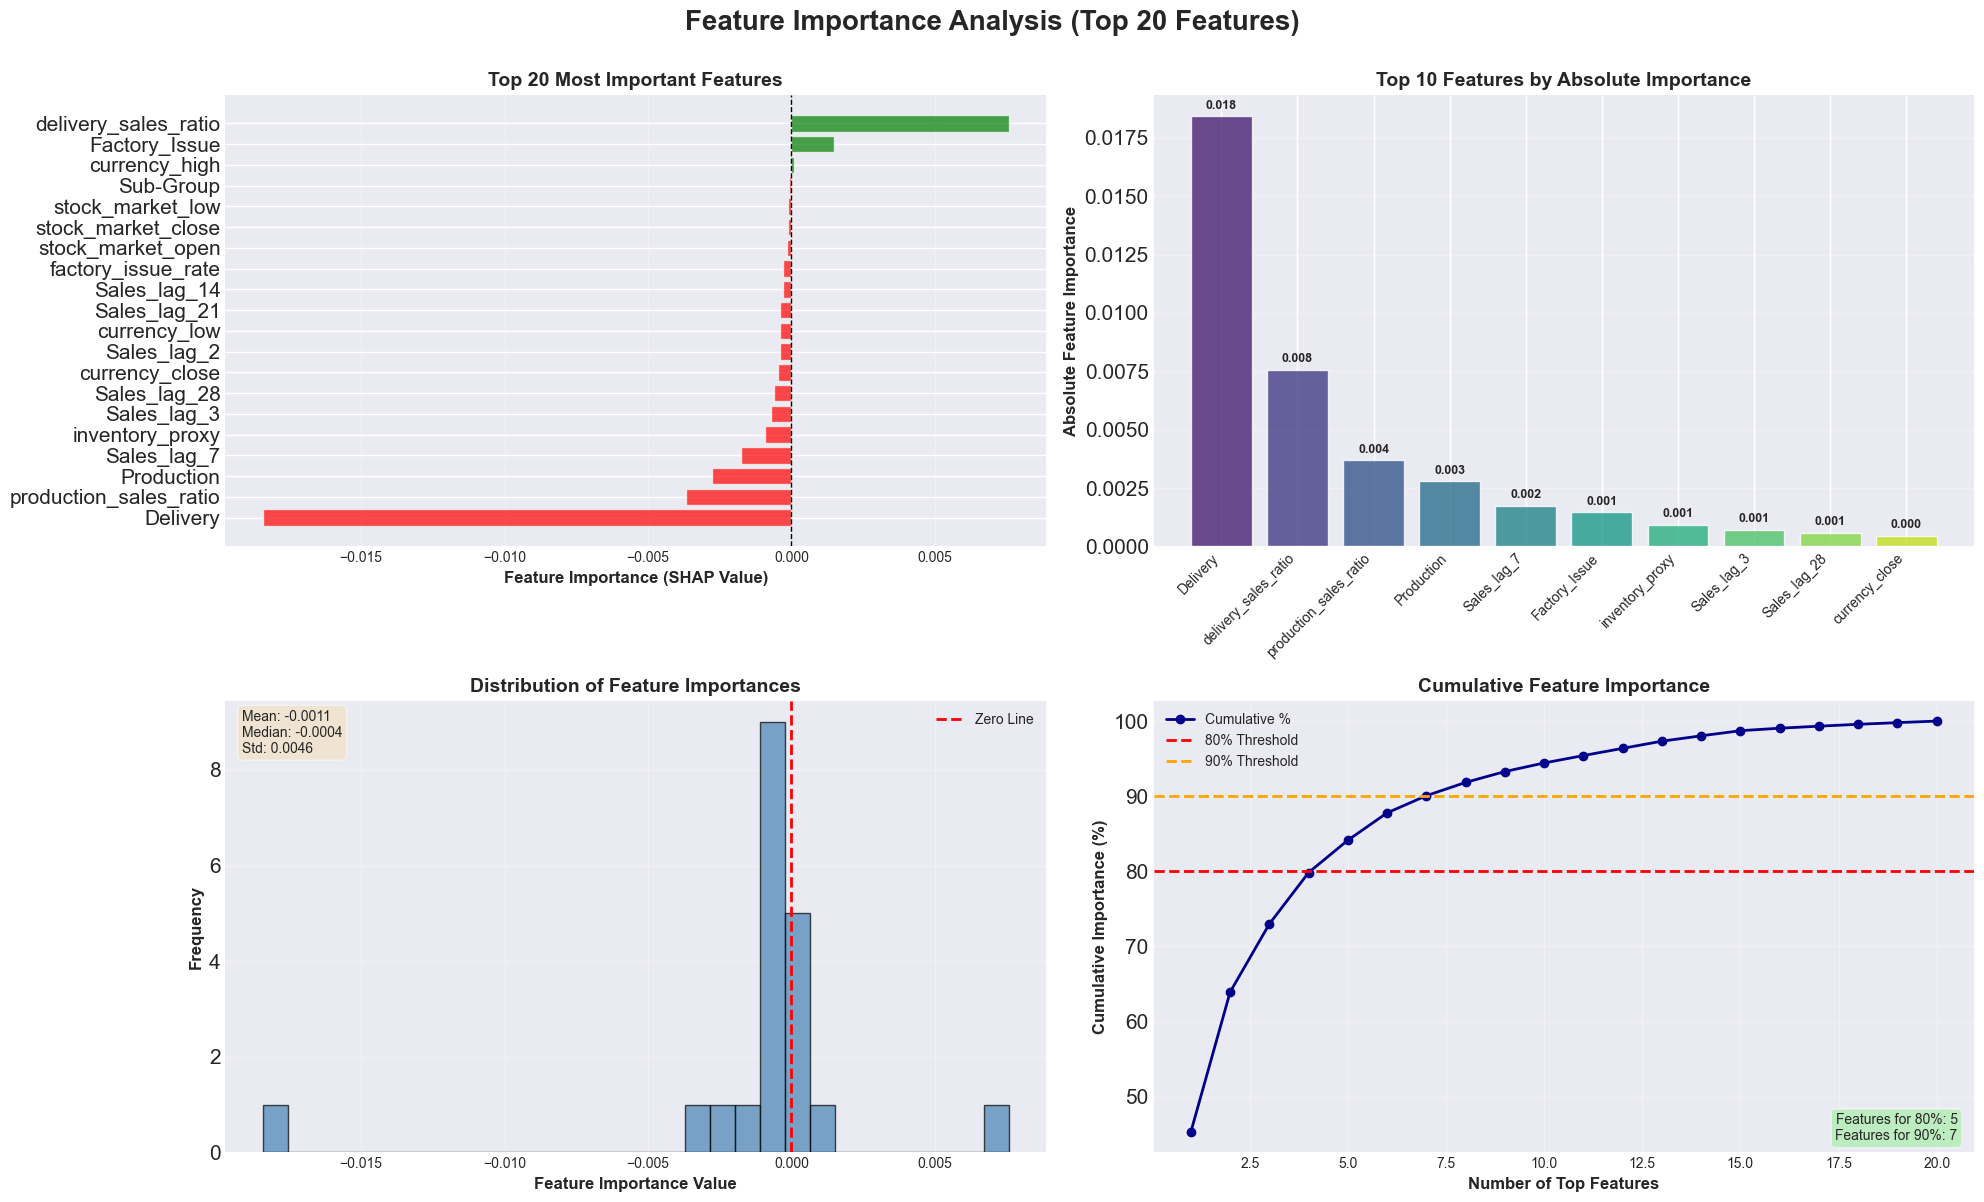


FEATURE IMPORTANCE SUMMARY STATISTICS (Top 20 Features)
Total features analyzed: 20
Positive importance features: 3
Negative importance features: 17
Mean importance: -0.001120
Median importance: -0.000389
Std deviation: 0.004596
Max importance: 0.007576 (delivery_sales_ratio)
Min importance: -0.018430 (Delivery)


,feature_name,feature_importance
0,Delivery,-0.018430
1,delivery_sales_ratio,0.007576
2,production_sales_ratio,-0.003690
3,Production,-0.002784
4,Sales_lag_7,-0.001752
5,Factory_Issue,0.001481
6,inventory_proxy,-0.000930
7,Sales_lag_3,-0.000720
8,Sales_lag_28,-0.000588
9,currency_close,-0.000465


In [46]:
def visualize_feature_importance(importance_df, top_n=20, x_fontsize=10, y_fontsize=10):
    """
    Visualize feature importance with multiple views.
    
    Parameters:
    -----------
    importance_df : pd.DataFrame
        DataFrame with columns 'feature_name' and 'feature_importance'
    top_n : int
        Number of top features to display (default: 20)
    x_fontsize : int
        Font size for x-axis labels (default: 10)
    y_fontsize : int
        Font size for y-axis labels (default: 10)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Set style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette('husl')
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.suptitle(f'Feature Importance Analysis (Top {top_n} Features)', fontsize=20, fontweight='bold', y=1.00)
    
    # 1. Top N Feature Importances - Horizontal Bar Chart
    ax1 = axes[0, 0]
    top_features = importance_df.head(top_n).sort_values('feature_importance', ascending=True)
    colors = ['green' if x > 0 else 'red' for x in top_features['feature_importance']]
    ax1.barh(range(len(top_features)), top_features['feature_importance'], color=colors, alpha=0.7)
    ax1.set_yticks(range(len(top_features)))
    ax1.set_yticklabels(top_features['feature_name'], fontsize=y_fontsize)
    ax1.set_xlabel('Feature Importance (SHAP Value)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
    ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax1.grid(axis='x', alpha=0.3)
    ax1.tick_params(axis='x', labelsize=x_fontsize)
    
    # 2. Top 10 Features - Vertical Bar Chart (Absolute Values)
    ax2 = axes[0, 1]
    top_10_display = min(10, top_n)
    top_10_abs = importance_df.head(top_10_display).copy()
    top_10_abs['abs_importance'] = top_10_abs['feature_importance'].abs()
    top_10_abs = top_10_abs.sort_values('abs_importance', ascending=False)
    colors_abs = sns.color_palette('viridis', len(top_10_abs))
    bars = ax2.bar(range(len(top_10_abs)), top_10_abs['abs_importance'], color=colors_abs, alpha=0.8)
    ax2.set_xticks(range(len(top_10_abs)))
    ax2.set_xticklabels(top_10_abs['feature_name'], rotation=45, ha='right', fontsize=x_fontsize)
    ax2.set_ylabel('Absolute Feature Importance', fontsize=12, fontweight='bold')
    ax2.set_title(f'Top {top_10_display} Features by Absolute Importance', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    ax2.tick_params(axis='y', labelsize=y_fontsize)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, top_10_abs['abs_importance'])):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(top_10_abs['abs_importance'])*0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 3. Feature Importance Distribution
    ax3 = axes[1, 0]
    ax3.hist(importance_df['feature_importance'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Line')
    ax3.set_xlabel('Feature Importance Value', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax3.set_title('Distribution of Feature Importances', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(alpha=0.3)
    ax3.tick_params(axis='x', labelsize=x_fontsize)
    ax3.tick_params(axis='y', labelsize=y_fontsize)
    
    # Add statistics text
    mean_imp = importance_df['feature_importance'].mean()
    median_imp = importance_df['feature_importance'].median()
    std_imp = importance_df['feature_importance'].std()
    stats_text = f'Mean: {mean_imp:.4f}\nMedian: {median_imp:.4f}\nStd: {std_imp:.4f}'
    ax3.text(0.02, 0.98, stats_text, transform=ax3.transAxes, 
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 4. Cumulative Importance (Top Features)
    ax4 = axes[1, 1]
    cumulative_n = min(30, len(importance_df))
    top_cumulative = importance_df.head(cumulative_n).copy()
    top_cumulative['abs_importance'] = top_cumulative['feature_importance'].abs()
    top_cumulative = top_cumulative.sort_values('abs_importance', ascending=False)
    top_cumulative['cumulative_importance'] = top_cumulative['abs_importance'].cumsum() / top_cumulative['abs_importance'].sum() * 100
    
    ax4.plot(range(1, len(top_cumulative) + 1), top_cumulative['cumulative_importance'], 
             marker='o', linewidth=2, markersize=6, color='darkblue', label='Cumulative %')
    ax4.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% Threshold')
    ax4.axhline(y=90, color='orange', linestyle='--', linewidth=2, label='90% Threshold')
    ax4.set_xlabel('Number of Top Features', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Cumulative Importance (%)', fontsize=12, fontweight='bold')
    ax4.set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(alpha=0.3)
    ax4.tick_params(axis='x', labelsize=x_fontsize)
    ax4.tick_params(axis='y', labelsize=y_fontsize)
    
    # Find how many features needed for 80% and 90%
    features_80 = (top_cumulative['cumulative_importance'] >= 80).idxmax() + 1 if any(top_cumulative['cumulative_importance'] >= 80) else len(top_cumulative)
    features_90 = (top_cumulative['cumulative_importance'] >= 90).idxmax() + 1 if any(top_cumulative['cumulative_importance'] >= 90) else len(top_cumulative)
    info_text = f'Features for 80%: {features_80}\nFeatures for 90%: {features_90}'
    ax4.text(0.98, 0.02, info_text, transform=ax4.transAxes, 
             fontsize=10, verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*80)
    print(f"FEATURE IMPORTANCE SUMMARY STATISTICS (Top {top_n} Features)")
    print("="*80)
    print(f"Total features analyzed: {len(importance_df)}")
    print(f"Positive importance features: {(importance_df['feature_importance'] > 0).sum()}")
    print(f"Negative importance features: {(importance_df['feature_importance'] < 0).sum()}")
    print(f"Mean importance: {importance_df['feature_importance'].mean():.6f}")
    print(f"Median importance: {importance_df['feature_importance'].median():.6f}")
    print(f"Std deviation: {importance_df['feature_importance'].std():.6f}")
    print(f"Max importance: {importance_df['feature_importance'].max():.6f} ({importance_df.loc[importance_df['feature_importance'].idxmax(), 'feature_name']})")
    print(f"Min importance: {importance_df['feature_importance'].min():.6f} ({importance_df.loc[importance_df['feature_importance'].idxmin(), 'feature_name']})")
    print("="*80)
    
    # Return top N features as a dataframe
    return importance_df.head(top_n)


# Example usage:
# visualize_feature_importance(importance_df, top_n=20, x_fontsize=10, y_fontsize=10)

# With larger font sizes
visualize_feature_importance(importance_df, top_n=20, x_fontsize=10, y_fontsize=15)

# With smaller font sizes for more features
# visualize_feature_importance(importance_df, top_n=30, x_fontsize=8, y_fontsize=8)

<br> <br> <br>

---

<br> <br> <br>